# Results

## SC Trials 03/02-12/02 (`data/sanity_checks`)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/complete_physics4/model_1.008e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.687880039215088, -2....",0.023147,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.405747413635254, 1.69102...",0.002726,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.658685445785522, -1.9...",0.004142,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.621750831604003, -1....",0.039594,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.426576972007751, 1.1514...",0.002743,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480870962142944, 2.8691...",0.012223,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6037119626998901, -1....",0.003548,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.710173368453979, 2.2700...",0.021869,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.542604684829712, -2....",0.054782,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.495648145675659, -1.6...",0.002041,0.0


In [2]:
# physics only 
import jax.numpy as jnp
from networks import DampedPendulumParamPDE
from forecasters import Forecaster
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")


In [3]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


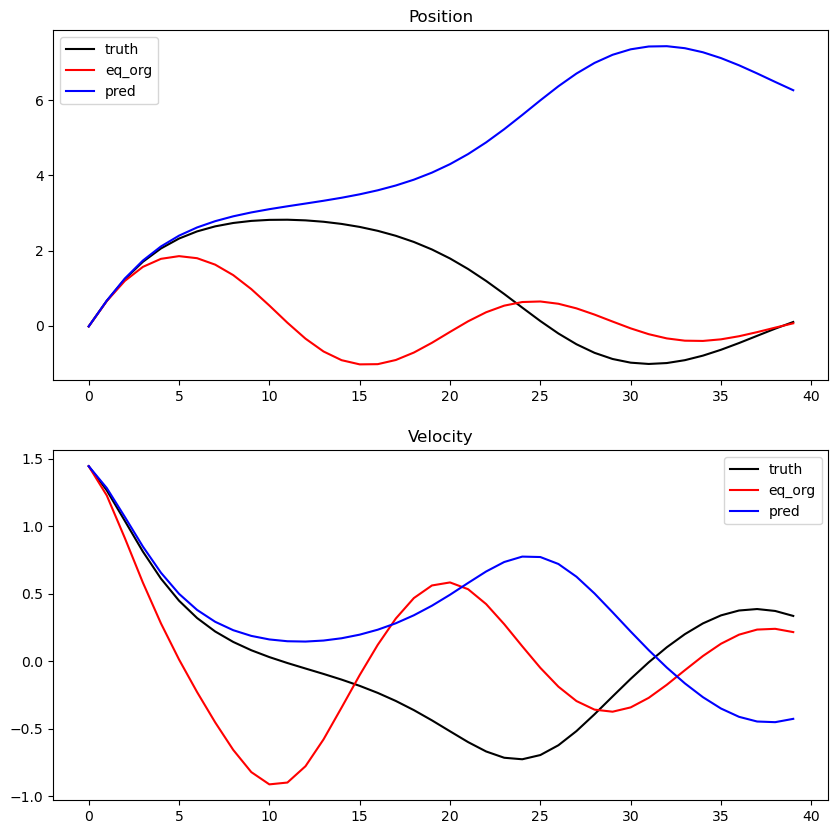

In [4]:
plot_trajectory(12)

[0.52782559 1.32926977]
(1, 2, 40)


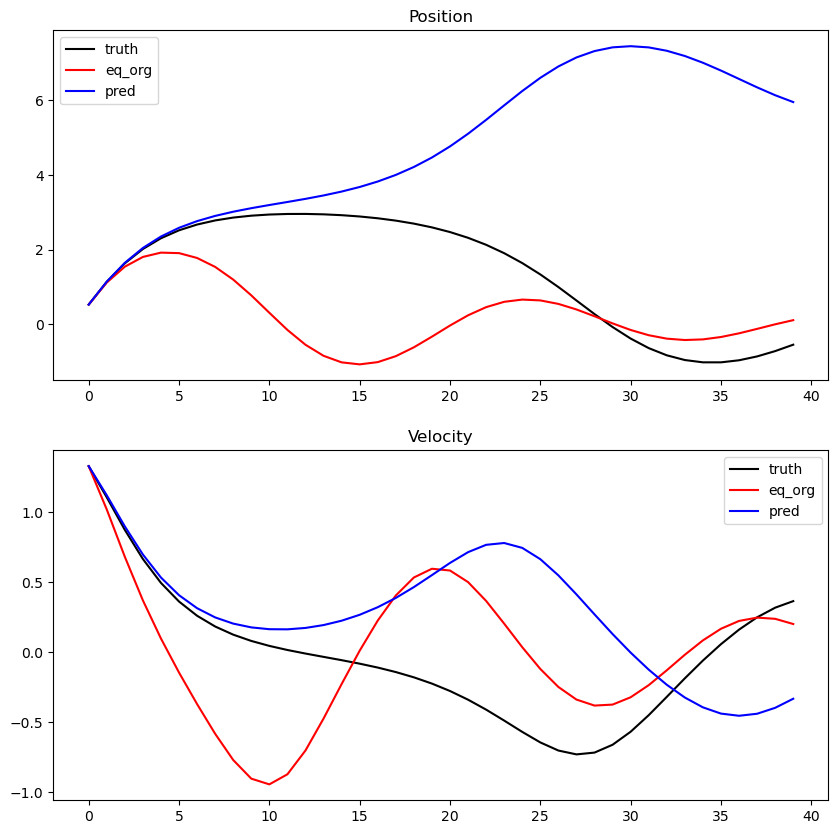

In [5]:
plot_trajectory(22)

[-1.34345663  0.41287747]
(1, 2, 40)


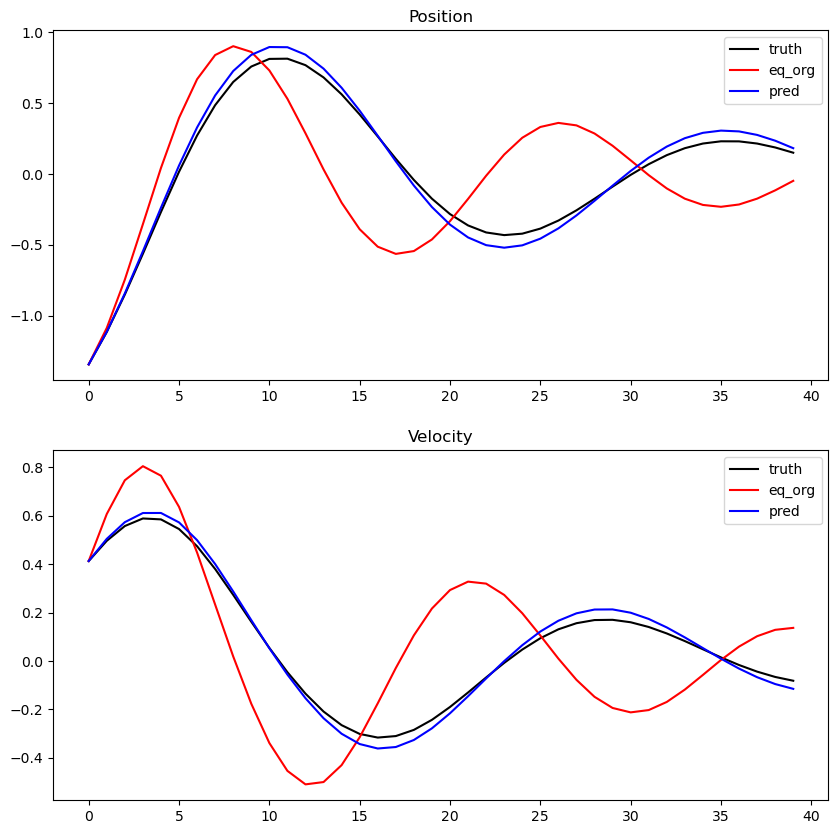

In [6]:
plot_trajectory(24)

In [10]:
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/incomplete_aug3/model_1.508e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.626970410346984, -2....",0.211602,0.002573
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.424392223358154, 1.74875...",0.378943,0.001084
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.628757238388061, -1.9...",0.237589,0.001309
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.6408729553222651, -1...",0.143368,0.002837
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.430660128593444, 1.1600...",0.170913,0.000969
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480446577072143, 2.8727...",0.112306,0.000886
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.574680805206298, -1.8...",0.24868,0.001296
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.737329006195068, 2.3514...",0.099819,0.000981
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.492254257202148, -2....",0.204859,0.002653
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.48915433883667, -1.61...",0.217697,0.001045


In [11]:
model_phy = DampedPendulumParamPDE(is_complete=False, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [12]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


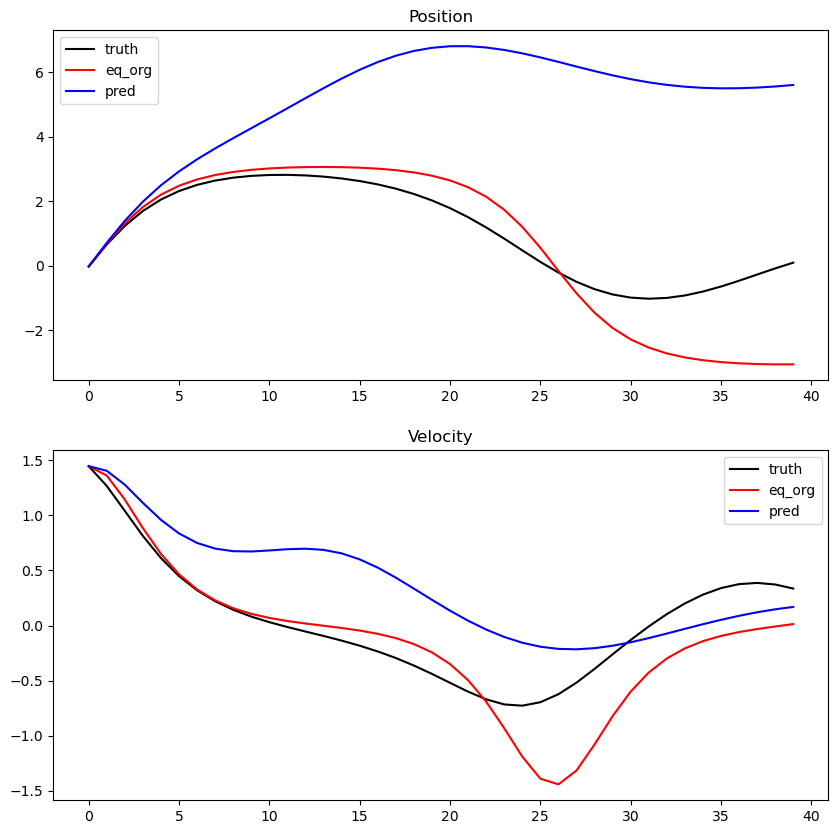

In [13]:
plot_trajectory(12)

[0.52782559 1.32926977]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


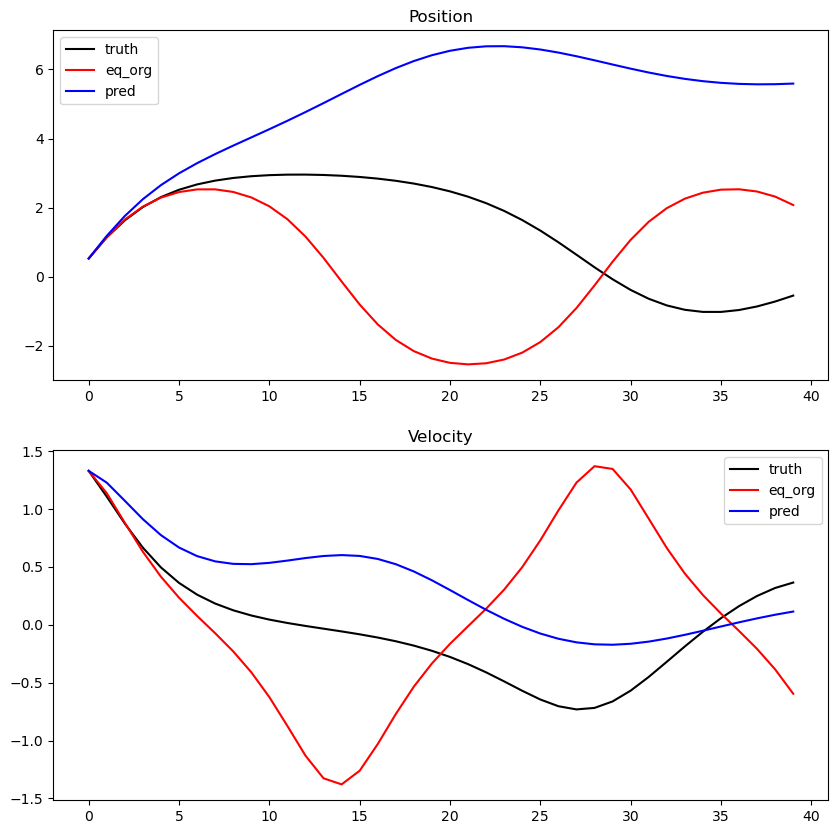

In [14]:
plot_trajectory(22)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


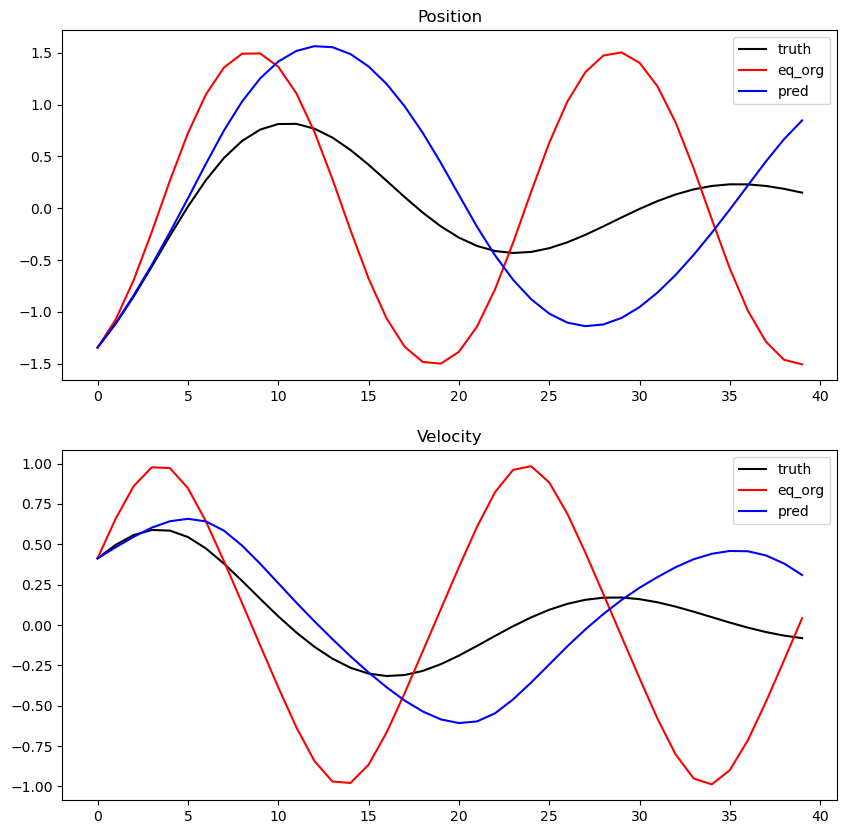

In [15]:
plot_trajectory(24)

### None aug5


In [16]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug5/model_1.006e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.6181092262268062, -2...",0.18581,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.340431213378906, 1.58105...",0.101088,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.637307405471801, -1.9...",0.098446,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.559412360191345, -1....",0.156073,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.369356155395507, 1.0821...",0.047644,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.45348310470581, 2.84081...",0.09176,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.582802057266235, -1.8...",0.092699,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.651341915130615, 2.2217...",0.062379,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.469146966934204, -2....",0.25517,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.483283877372741, -1.5...",0.04442,0.0


In [17]:
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [18]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


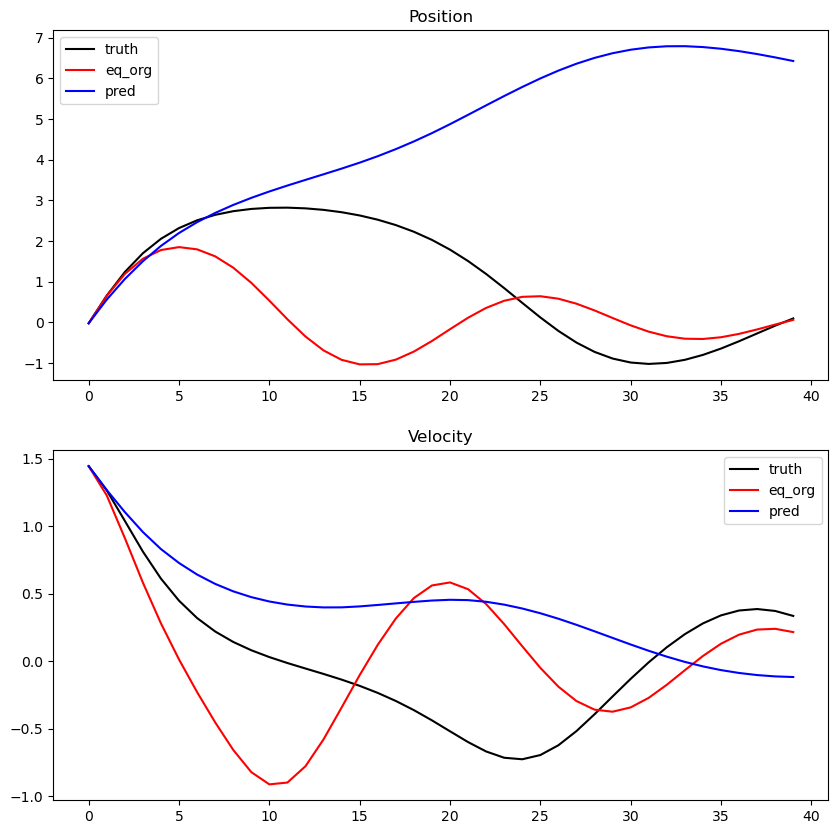

In [19]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


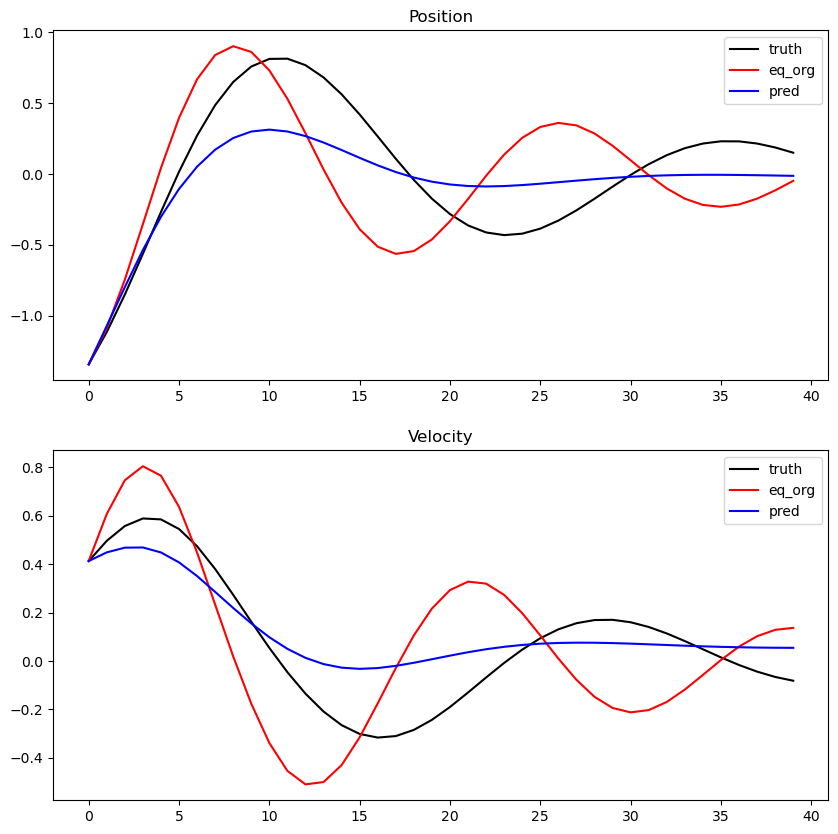

In [20]:
plot_trajectory(24)

### none aug6 

In [22]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug6/model_1.784e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.545371651649475, -2....",0.423295,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.3244702816009521, 1.6016...",1.66484,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.612063407897949, -1.9...",1.102503,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.47063967585563604, -...",0.314862,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.383215904235839, 1.1161...",0.088045,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.423594713211059, 2.8058...",0.327988,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.557781219482421, -1.8...",1.027345,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.577638626098632, 2.1117...",0.171073,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.380985379219055, -2....",0.483737,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.486307859420776, -1.6...",0.317323,0.0


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


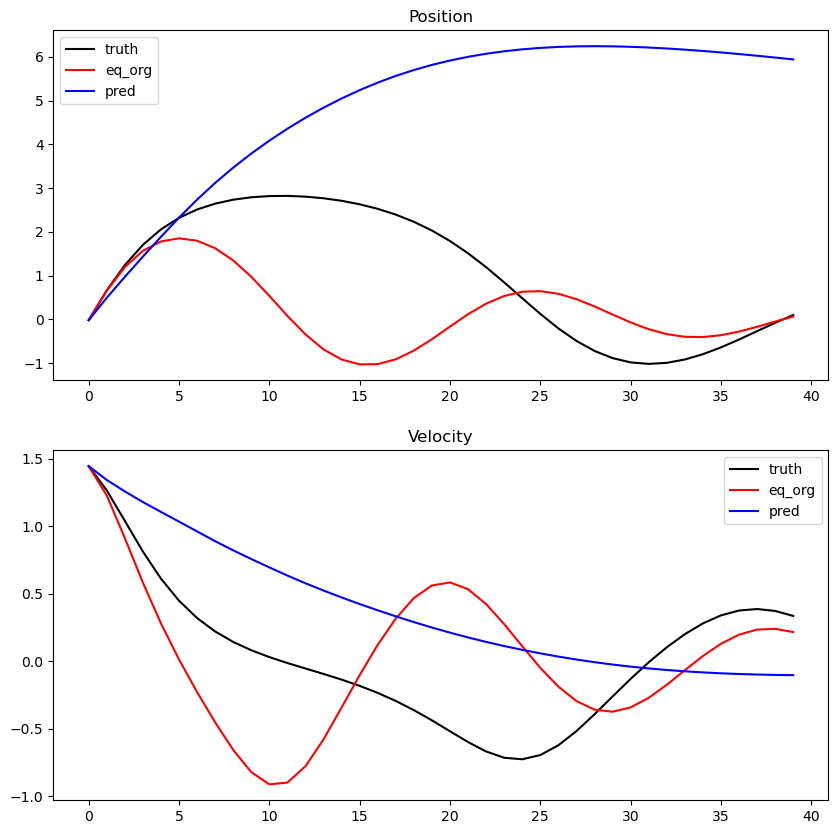

In [24]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


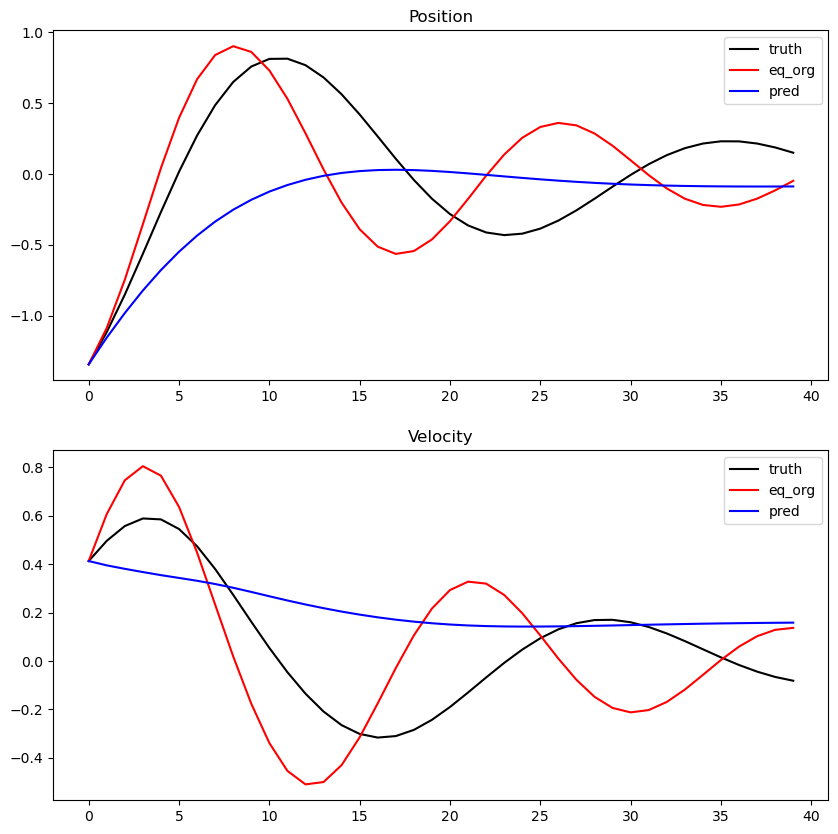

In [25]:
plot_trajectory(24)

## SC Trials debug (`data/tests`)

### None 11

In [20]:
import pandas as pd
results_pth = "/Users/mayajanvier/jax-phynity/data/tests/none_aug_9_se3z528o/model_1.422e-02..json"
results = pd.read_json(results_pth).T
results

ValueError: Trailing data

In [2]:
from networks import PendulumParamPDE
from forecasters import *
model_phy = PendulumParamPDE(is_damped=True, params={"omega0_square": (2*jnp.pi/12)**2, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete",dt=0.5, num_steps=40, integration_method="RK4")

In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np


In [4]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = jax.vmap(net_phy)(np.array([results["states"][index]])[:,:,0])
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

In [9]:
phy_out = jax.vmap(net_phy)(np.array([results["states"][1]])[:,:,0])
(np.array(results["states"][1][1]) - np.array(phy_out[0,1,:])).mean()

1.9989363480438227e-09

In [10]:
phy_out2 =jax.vmap(net_phy)(np.array([results["states"][1]])[:,:,0])
(np.array(phy_out[0,1,:]) - np.array(phy_out2[0,1,:])).mean()

0.0

In [14]:
phy_out2 = np.array(phy_out2)
phy_out_jnp = jnp.array(phy_out2)
(phy_out_jnp-phy_out).mean()

Array(0., dtype=float32)

[0.52782559 1.32926977]
(1, 2, 41)


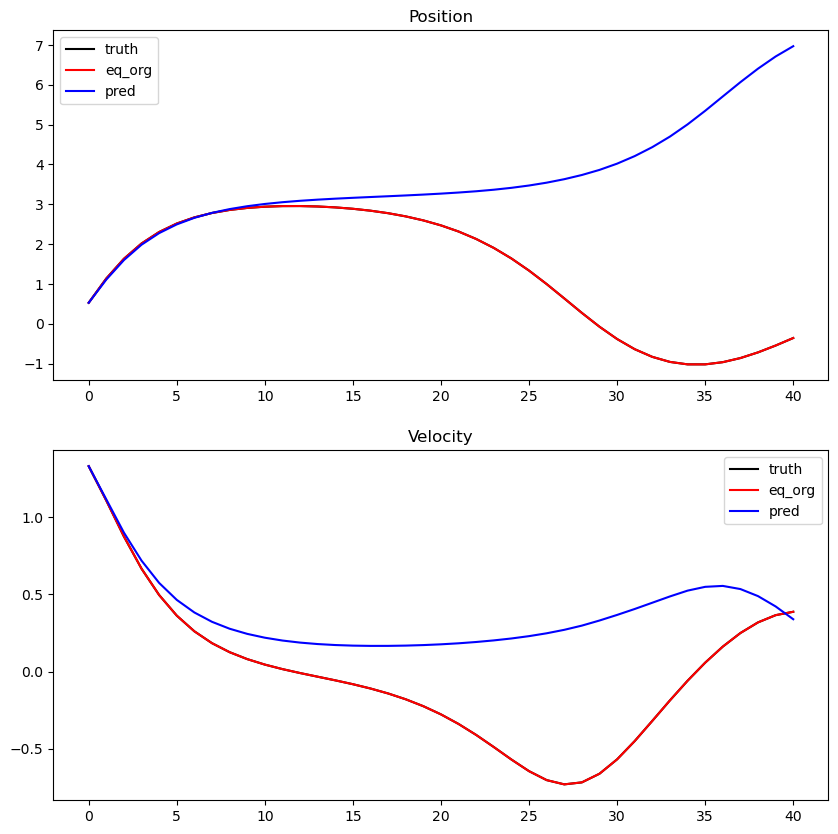

In [5]:
plot_trajectory(22)

[-1.34345663  0.41287747]
(1, 2, 41)


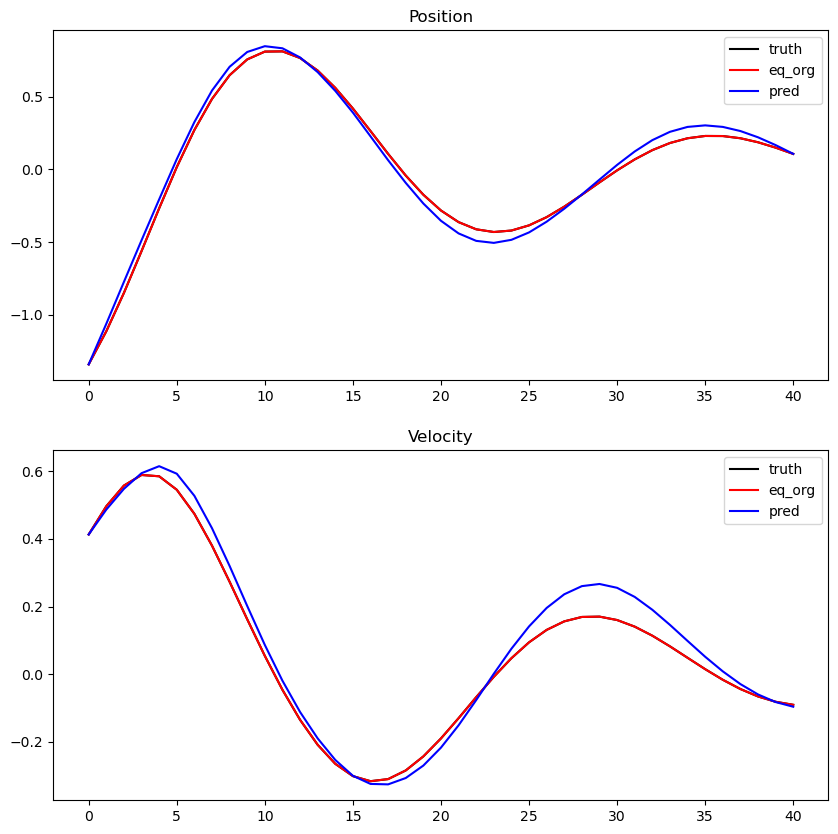

In [11]:
plot_trajectory(24)

## SC Trials 17/02 (`data/sanity_checks2`)

In [268]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

In [269]:
def load_results(results_pth):
    results = pd.read_json(results_pth).T
    exp_name = results_pth.split("/")[-2]
    val_loss = float(results_pth.split("_")[-1][:-6])

    # add initial conditions to dataframe
    results["q0"] = results["states"].apply(lambda x: x[0][0])
    results["p0"] = results["states"].apply(lambda x: x[1][0])
    return results, exp_name, val_loss

In [288]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_14_d7l5vx50/model_1.132e-03.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('complete_physics_14_d7l5vx50', 1.132)

In [289]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682531356811523, -2....",0.000367,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403149604797363, 1.68172...",0.001082,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.65600299835205, -1.94...",0.001977,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.616124749183654, -1....",0.000474,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.427735567092895, 1.1563...",0.000238,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.47775387763977, 2.85766...",0.000416,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6010524034500122, -1....",0.001667,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.7057180404663081, 2.253...",0.000321,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.53653860092163, -2.3...",0.000355,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494138717651367, -1.6...",0.000535,0.0,-1.292473,-0.493132


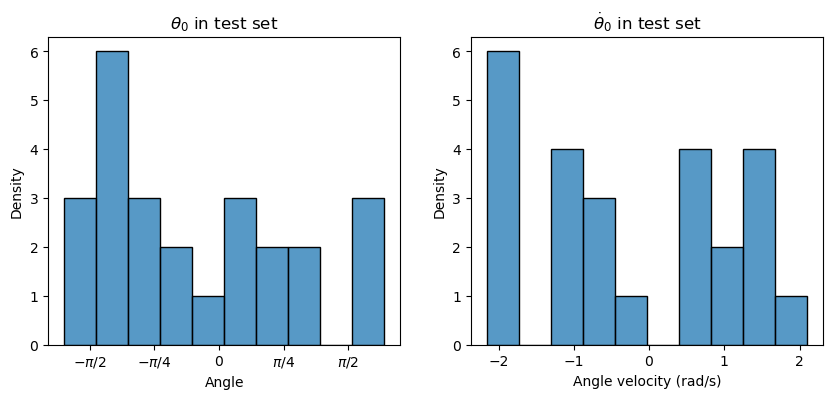

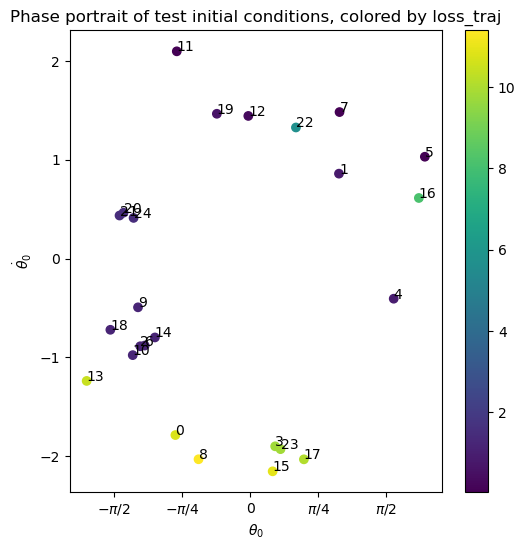

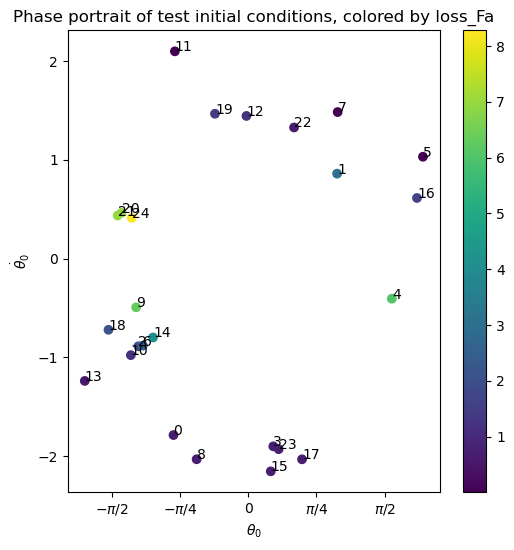

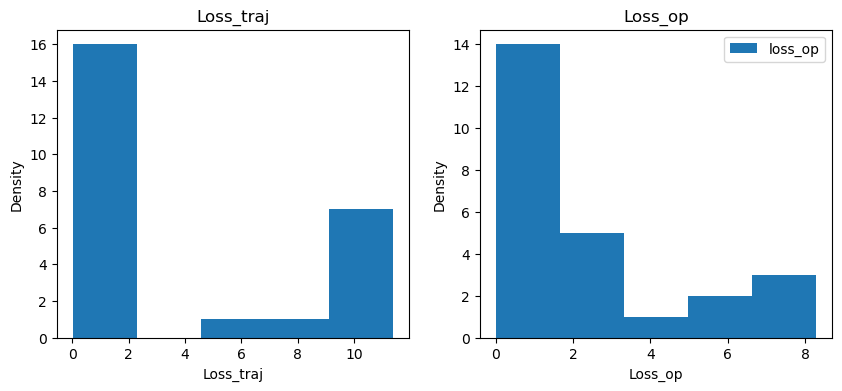

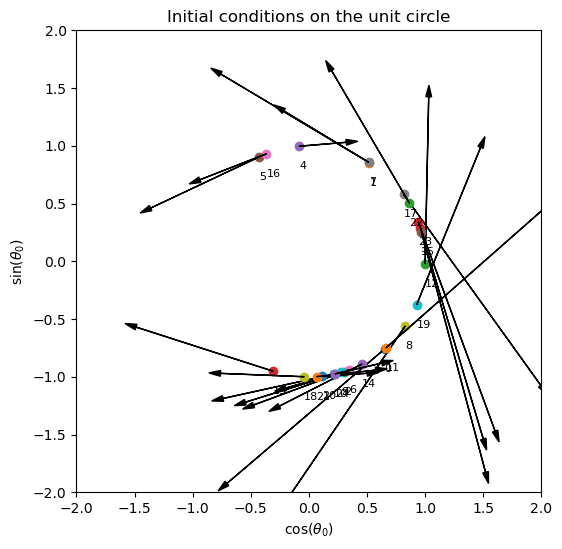

In [328]:
def viz_CI_regimes(res, type="test"):
    # subplot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # choose boxes of the histogram
    sns.histplot(res["q0"], ax=ax[0], bins=10)
    ax[0].set_title(rf"$\theta_0$ in {type} set")
    ax[0].set_xlabel("Angle")
    ax[0].set_ylabel("Density")
    ax[0].set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax[0].set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])

    sns.histplot(res["p0"], ax=ax[1], bins=10)
    ax[1].set_title(fr"$\dot\theta_0$ in {type} set")
    ax[1].set_xlabel("Angle velocity (rad/s)")
    ax[1].set_ylabel("Density")
    plt.show()

    # portrait de phase 
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    # put index of traj above the point
    for i, txt in enumerate(res.index):
        ax.annotate(txt, (res["q0"][i], res["p0"][i]))
    if type == "train":
        plt.scatter(res["q0"], res["p0"], label="Initial conditions")
        plt.title(f"Phase portrait of {type} initial conditions")
    else:
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_traj"], cmap="viridis")
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_traj")
        plt.colorbar()
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\dot{\theta}_0$")
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
    
    plt.show()

    # portrait de phase colored by loss_Fa
    if type != "train":
        fig, ax = plt.subplots(1,1,figsize=(6, 6))
        # put index of traj above the point
        for i, txt in enumerate(res.index):
            ax.annotate(txt, (res["q0"][i], res["p0"][i]))
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_op"], cmap="viridis")
        plt.xlabel(r"$\theta_0$")
        plt.ylabel(r"$\dot{\theta}_0$")
        ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
        ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
        plt.colorbar()
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_Fa")
        plt.show()

        # histograms of loss_traj and loss_op
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        res["loss_traj"].plot.hist(ax=ax[0], bins=5)
        ax[0].set_title(r"Loss_traj")
        ax[0].set_xlabel("Loss_traj")
        ax[0].set_ylabel("Density")
        res["loss_op"].plot.hist(ax=ax[1], bins=5)
        ax[1].set_title(r"Loss_op")
        ax[1].set_xlabel("Loss_op")
        ax[1].set_ylabel("Density")
        plt.legend()
        plt.show()


    # circular histogram
    # square figure
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    for i, txt in enumerate(res.index):
        # position
        theta = res["q0"][i]
        plt.scatter(np.cos(theta),np.sin(theta))
        ax.annotate(txt, (np.cos(theta),np.sin(theta)-0.2), fontsize=8)
        # add arrow for velocity
        norm = res["p0"][i]
        ax.arrow(np.cos(theta), np.sin(theta), -norm*np.sin(theta), norm*np.cos(theta), head_width=0.05, head_length=0.1, fc='k', ec='k')
    plt.ylim([-2,2])
    plt.xlim([-2,2])
    plt.xlabel(r"cos($\theta_0$)")
    plt.ylabel(r"sin($\theta_0$)")
    plt.title("Initial conditions on the unit circle")


viz_CI_regimes(results)

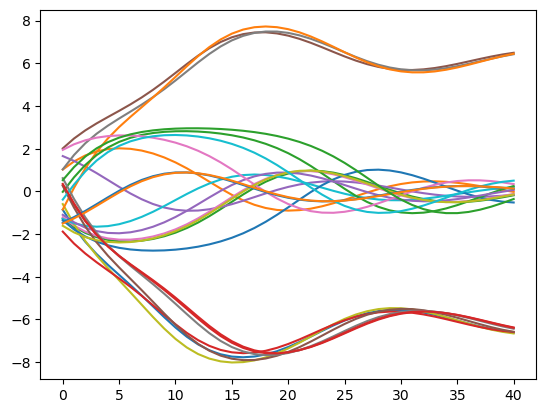

In [291]:
for index in range(24):
    states = np.array(results["states"][index])
    plt.plot(states[0], label="q")

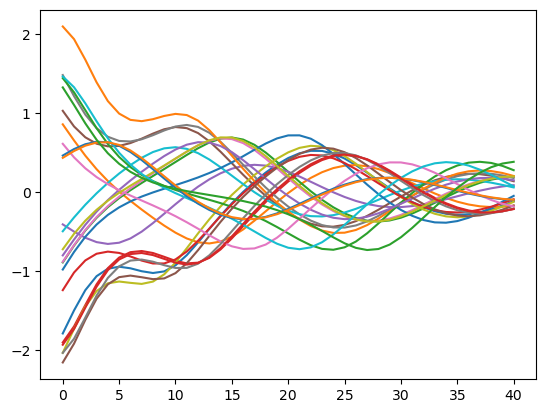

In [292]:
for index in range(24):
    states = np.array(results["states"][index])
    plt.plot(states[1], label="p")

In [323]:
def plot_trajectory(res, exp, index):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    y0 = np.array(res["states"][index])[:,0]
    # set y max
    ax[0].set_ylim([-8, 8])
    ax[1].set_ylim([-2.1,2.1])

    ax[0].set_title(f"Trajectory {index}: position, q0={round(float(y0[0]),3)}") 
    ax[0].plot(np.array(res["states"][index][0]), label="truth", color="gray")
    ax[0].plot(np.array(res["pred"][index][0]), label="pred", color="darkorange")
    # add regime areas
    # multiples de 2pi
    null_angles = [k*np.pi for k in range(-2, 3, 2)]
    i=0
    for angle in null_angles:
        if i ==0:
            ax[0].axhline(y=angle, color='black', linestyle='--', label="q=0", alpha=0.5)
        else:
            ax[0].axhline(y=angle, color='black', linestyle='--', alpha=0.5)
        i+=1
    ax[0].axhline(y=np.pi, color='orangered', linestyle='--', label="turn", alpha=0.5)
    ax[0].axhline(y=-np.pi, color='orangered', linestyle='--', alpha=0.5)
    # set ticks with labels
    ax[0].set_yticks(null_angles + [np.pi, -np.pi])
    # write pi in latex style
    ax[0].set_yticklabels(["-2$\pi$", "0",  "2$\pi$", "$\pi$", "-$\pi$"])
    ax[0].set_xlabel("Time steps")
    ax[0].set_ylabel("Angle (rad)")
    ax[0].legend()

    ax[1].set_title(f"Trajectory {index}: velocity, p0={round(float(y0[1]),3)}")
    ax[1].plot(np.array(res["states"][index][1]), label="truth", color="gray")
    ax[1].plot(np.array(res["pred"][index][1]), label="pred", color="darkorange")
    # null velocity line
    ax[1].axhline(y=0, color='black', linestyle='--', label="p=0", alpha=0.5)   
    ax[1].set_xlabel("Time steps")
    ax[1].set_ylabel("Angle velocity (rad/s)")
    ax[1].legend()

    fig.suptitle(f"Experiment: {exp}, loss_traj={round(res['loss_traj'][index],5)}, loss_op={round(res['loss_op'][index],5)}")
    plt.show()
    

## Train data 

In [294]:
# train data viz
from datasets import * 
import os
path = 'data/sanity_checks2'
dataset_name = 'pendulum'
train, _,_ = init_dataloaders("pendulum", 'RK4', os.path.join(path, dataset_name))

train.dataset

In [295]:
for i, train_data in enumerate(train):
    print(train_data["states"].shape)

torch.Size([25, 2, 41])


In [296]:
y0 = train_data["states"][:,:,0]
y0 = pd.DataFrame(y0, columns=["q0", "p0"])
y0

,q0,p0
0,-1.334527,0.894015
1,-0.144654,-2.158659
2,0.262720,1.561437
3,1.402906,1.221938
4,1.519548,-1.305323
5,2.101425,-0.089342
6,1.486833,-0.771030
7,1.659655,1.451410
8,1.759936,-0.704725
9,-0.974419,-1.359348


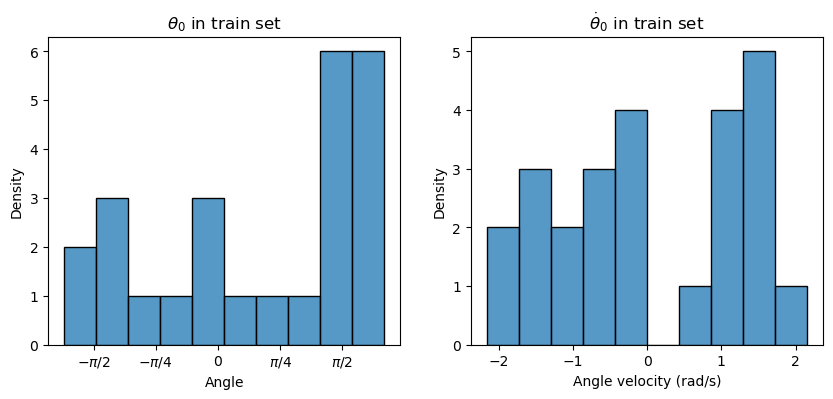

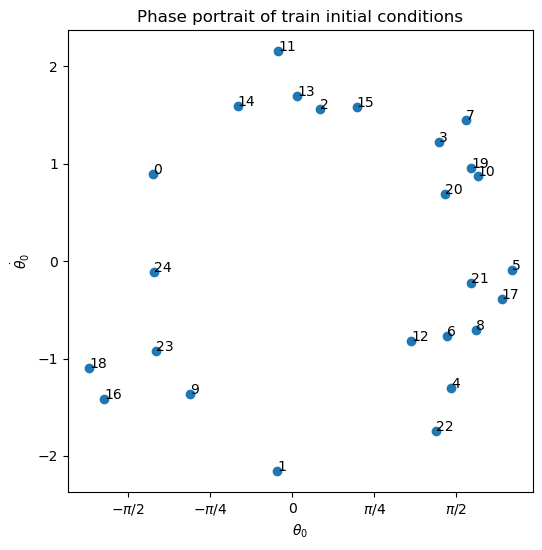

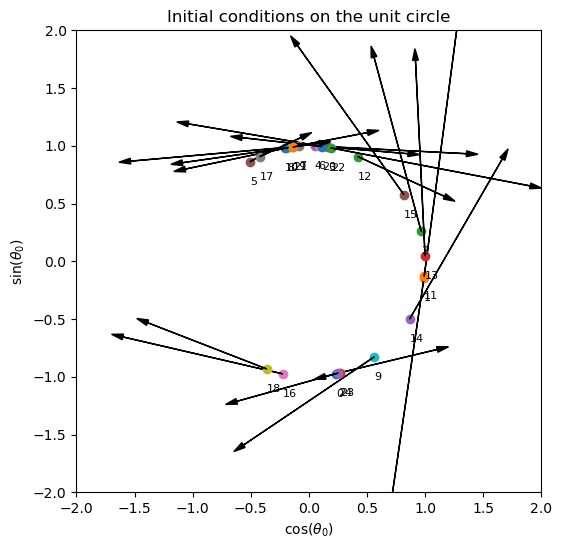

In [297]:
viz_CI_regimes(y0, type="train")

## None aug 16

In [298]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/none_aug_16_1m63z5th/model_6.047e-02..json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('none_aug_16_1m63z5th', 0.06047)

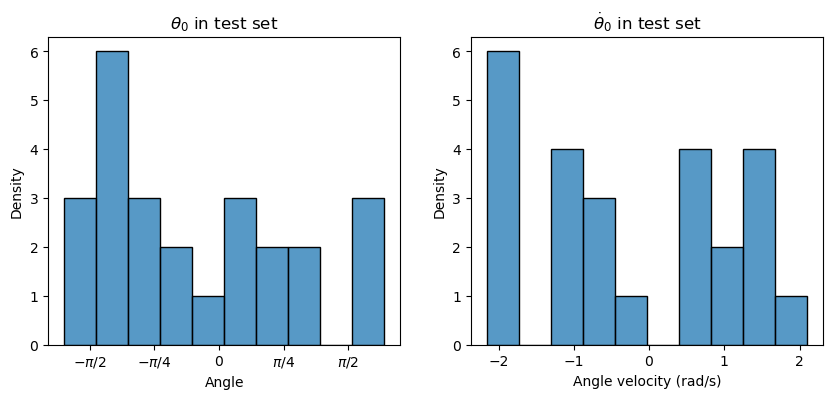

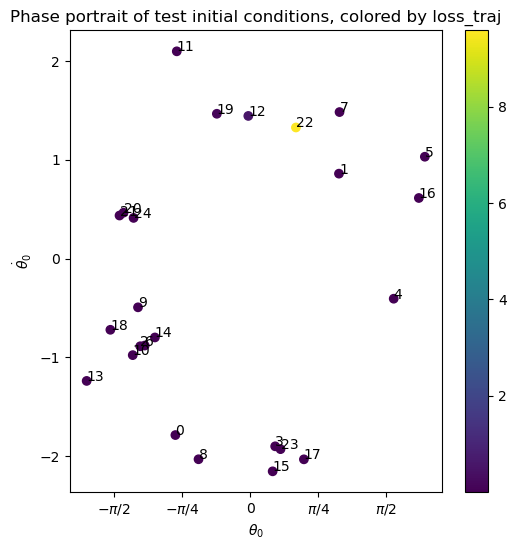

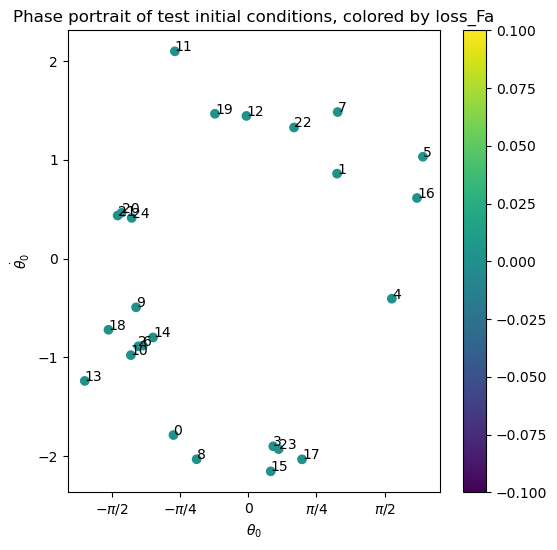

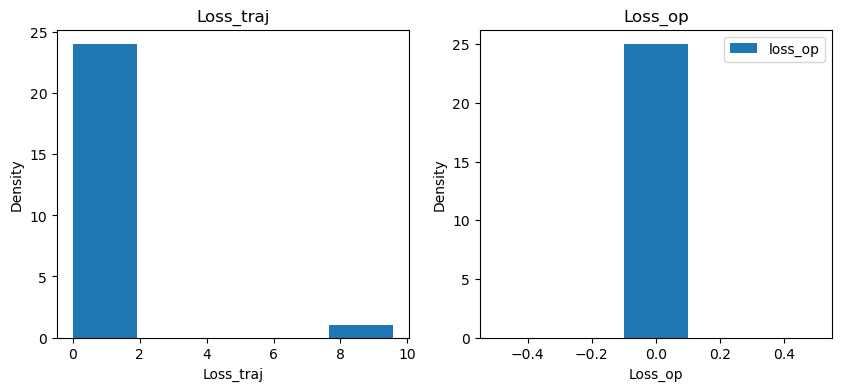

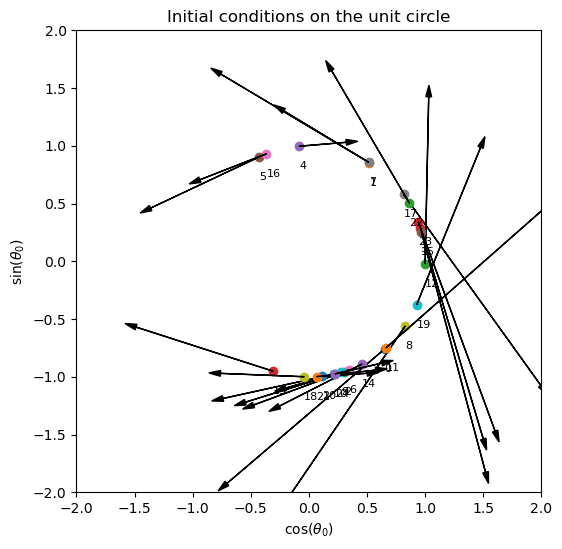

In [299]:
viz_CI_regimes(results)

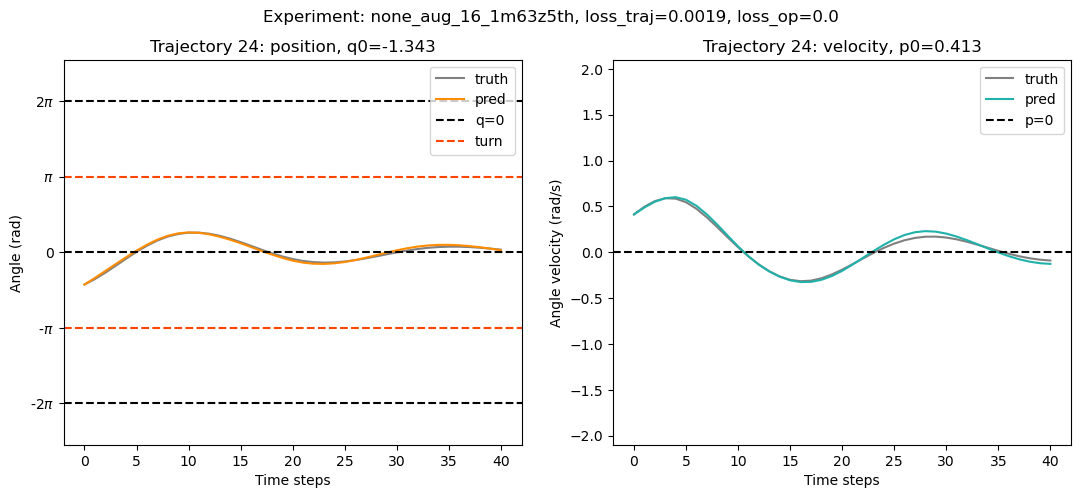

In [300]:
plot_trajectory(results, exp_name, 24)

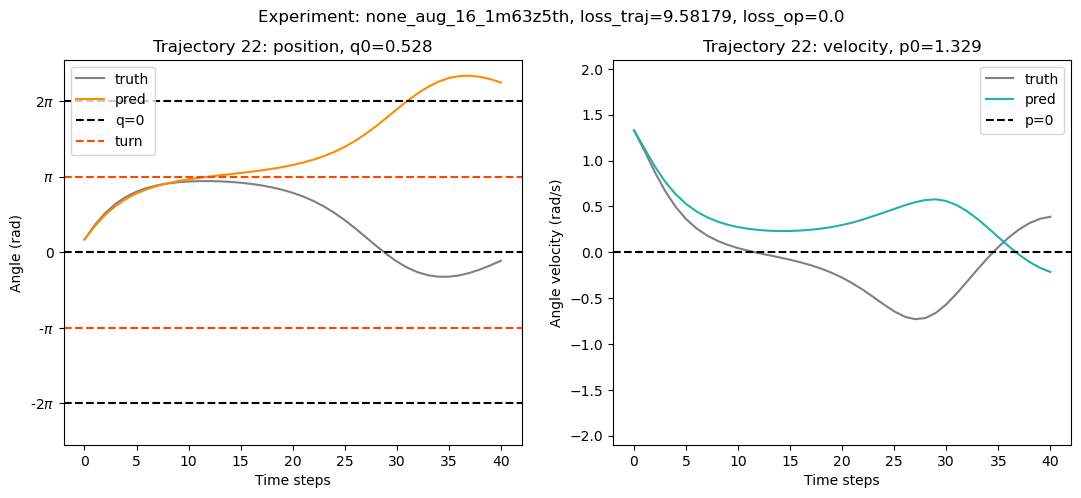

In [301]:
plot_trajectory(results, exp_name, 22)

## complete physics 14

Final omega: 0.28003543615341187, Final alpha: 0.196983486413955

In [302]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_14_d7l5vx50/model_1.132e-03.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('complete_physics_14_d7l5vx50', 1.132)

In [303]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682531356811523, -2....",0.000367,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403149604797363, 1.68172...",0.001082,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.65600299835205, -1.94...",0.001977,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.616124749183654, -1....",0.000474,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.427735567092895, 1.1563...",0.000238,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.47775387763977, 2.85766...",0.000416,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6010524034500122, -1....",0.001667,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.7057180404663081, 2.253...",0.000321,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.53653860092163, -2.3...",0.000355,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494138717651367, -1.6...",0.000535,0.0,-1.292473,-0.493132


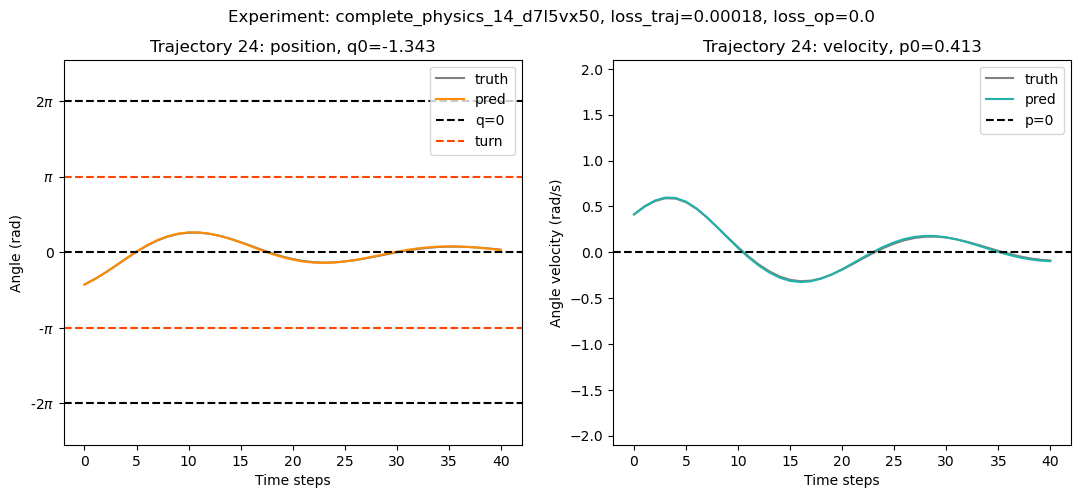

In [304]:
plot_trajectory(results, exp_name, 24)

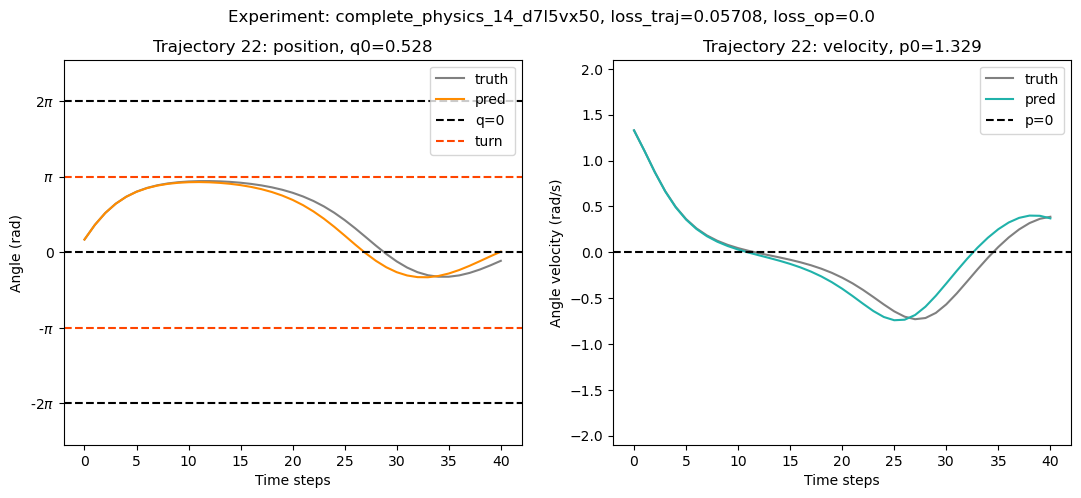

In [305]:
plot_trajectory(results, exp_name, 22)

### incomplete aug 17: wrong loss 
Final omega: 0.2073115110397339, Final alpha: 0.0

In [306]:
path = '/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_17_m9bz4n8c/model_2.790e+00.json'
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('incomplete_aug_17_m9bz4n8c', 2.79)

In [307]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.6506702899932861, -2...",0.143378,0.001966,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.429108142852783, 1.76517...",1.285091,0.000516,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.638038635253906, -1.9...",0.632978,0.001288,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.626850128173828, -1....",0.069507,0.001914,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.4389311075210571, 1.179...",0.347999,0.000442,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.484290599822998, 2.8936...",0.034732,0.000359,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.58401083946228, -1.87...",0.609975,0.001255,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.739323139190673, 2.3589...",0.145952,0.000423,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.510691046714782, -2....",0.1201,0.002042,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494427680969238, -1.6...",0.399011,0.000848,-1.292473,-0.493132


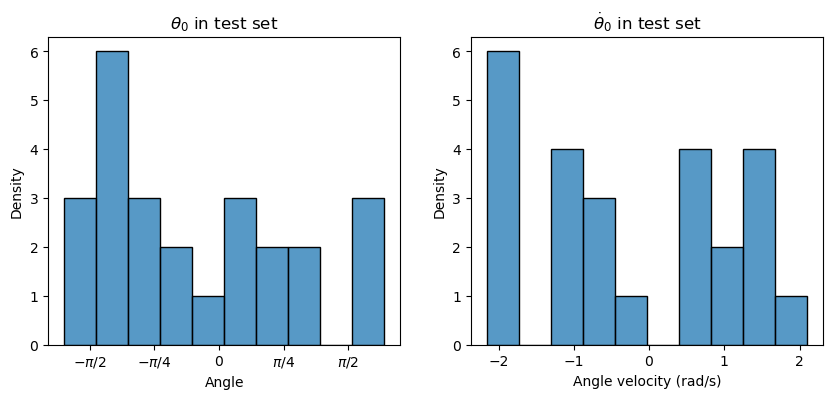

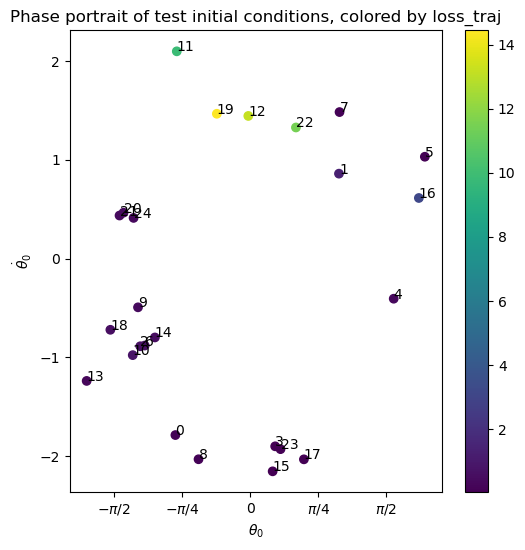

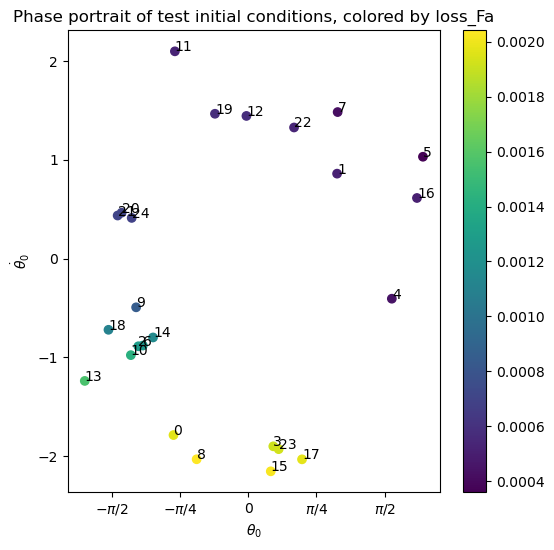

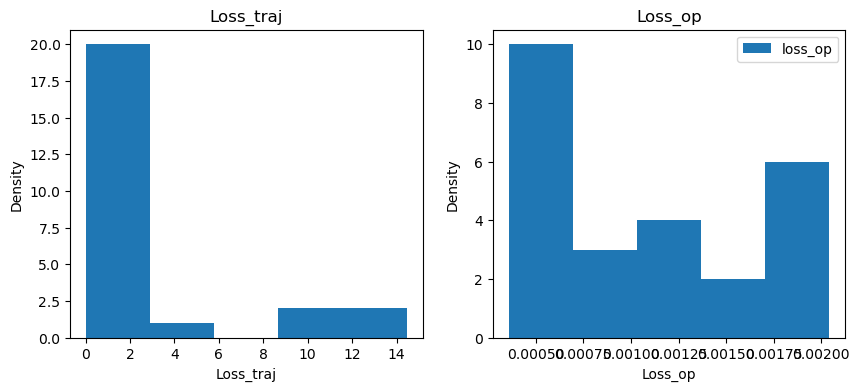

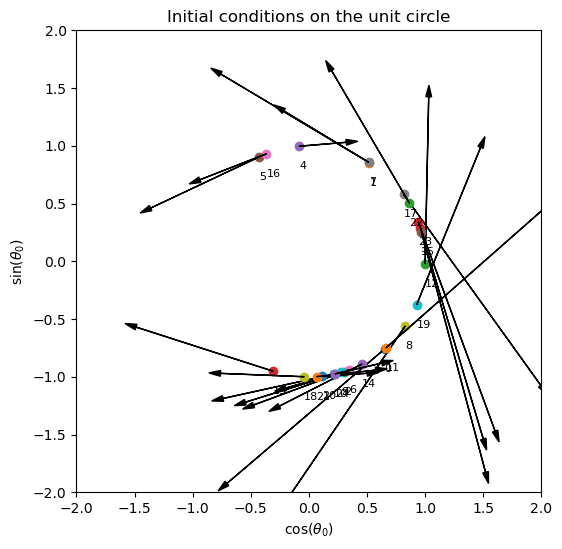

In [308]:
viz_CI_regimes(results)

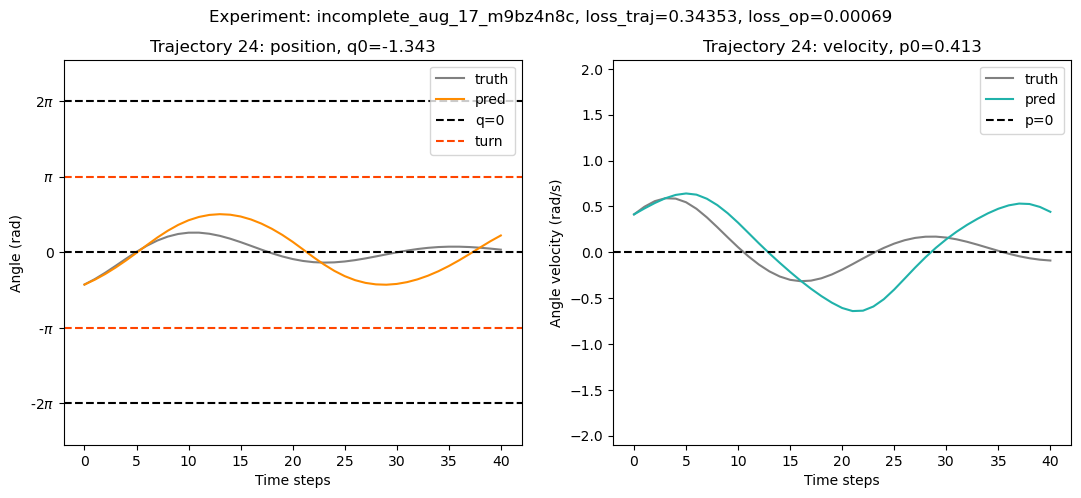

In [233]:
plot_trajectory(results, exp_name, 24)

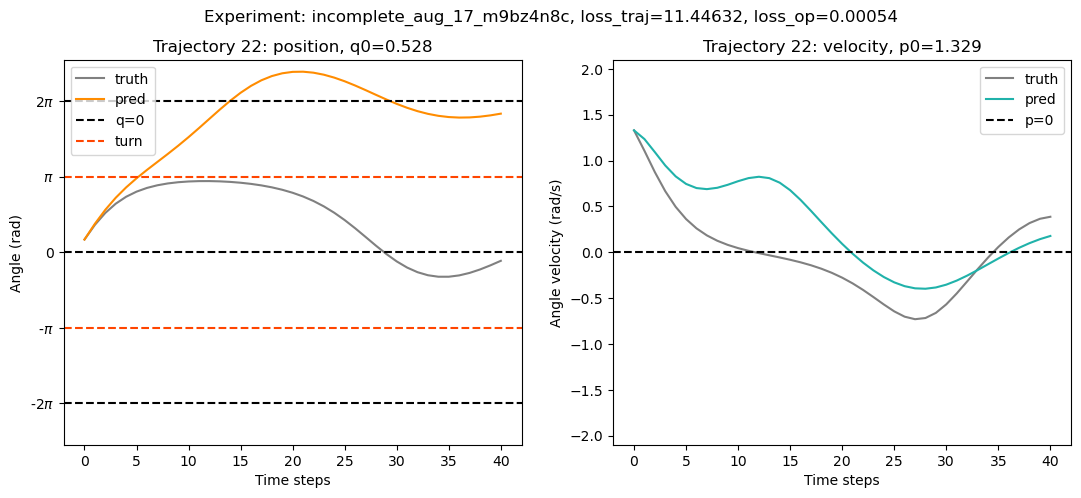

In [234]:
plot_trajectory(results, exp_name, 22)

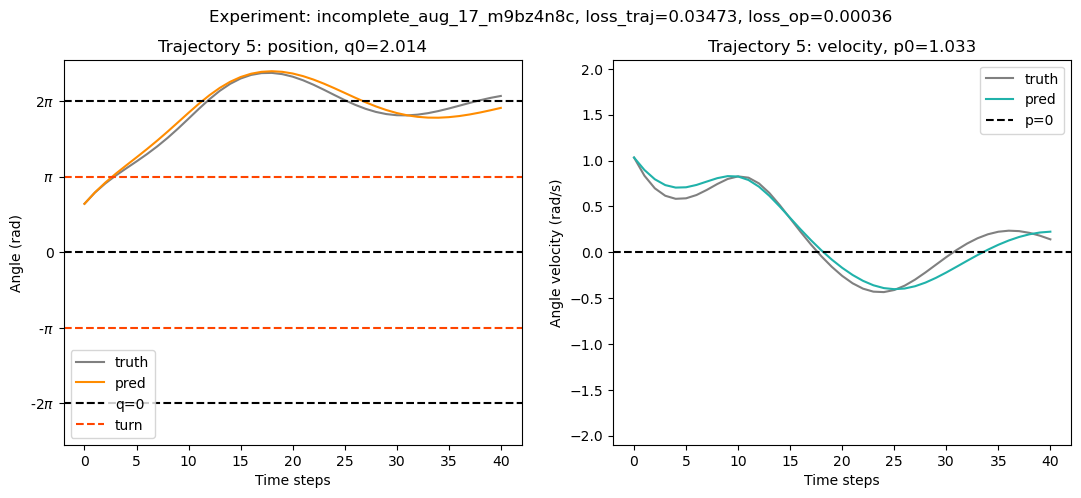

In [235]:
plot_trajectory(results, exp_name, 5)

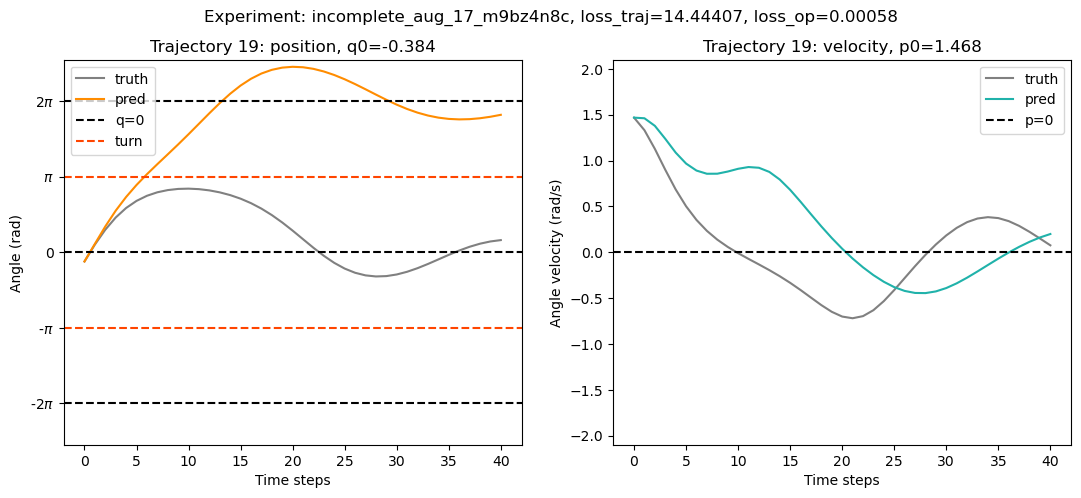

In [236]:
plot_trajectory(results, exp_name, 19)

## incomplete aug 19
Final omega: 0.22525587677955627, Final alpha: 0.0

In [309]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_19_korcnphf/model_2.400e+00.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('incomplete_aug_19_korcnphf', 2.4)

In [310]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.277207612991333, -1....",10.760328,0.611657,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.263813138008117, 1.43468...",0.818055,3.079111,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.395644307136535, -1.4...",1.165683,2.029806,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.26815548539161604, -...",9.761674,0.691293,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.33664870262146, 1.00300...",0.94818,6.029916,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.424787759780884, 2.7662...",0.038825,0.000919,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.352573156356811, -1.3...",1.162419,2.388407,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.646154522895813, 2.1580...",0.031189,0.001775,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.120106697082519, -1....",11.397531,0.622855,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.359453797340393, -1.4...",1.19821,6.289103,-1.292473,-0.493132


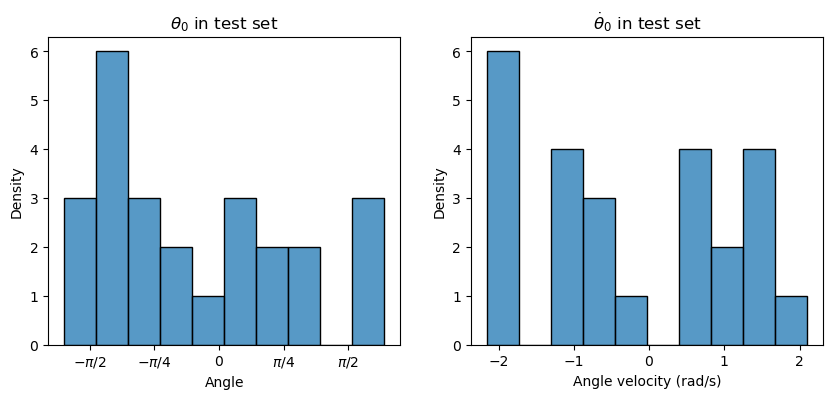

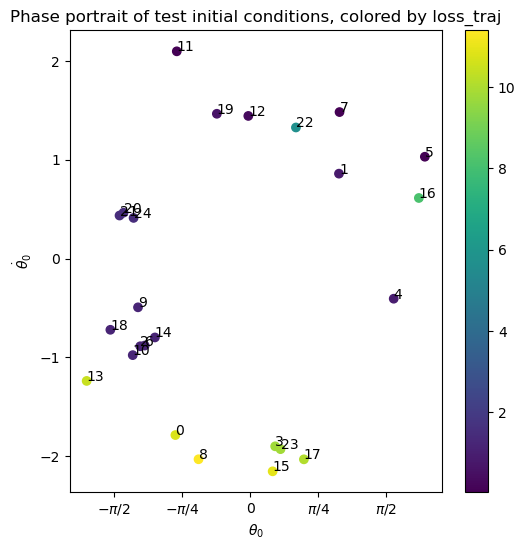

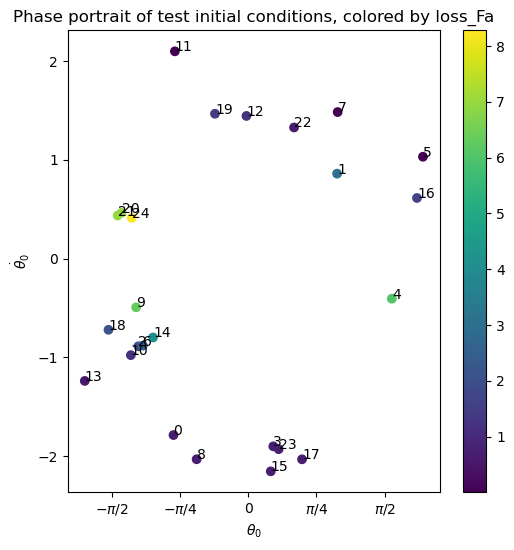

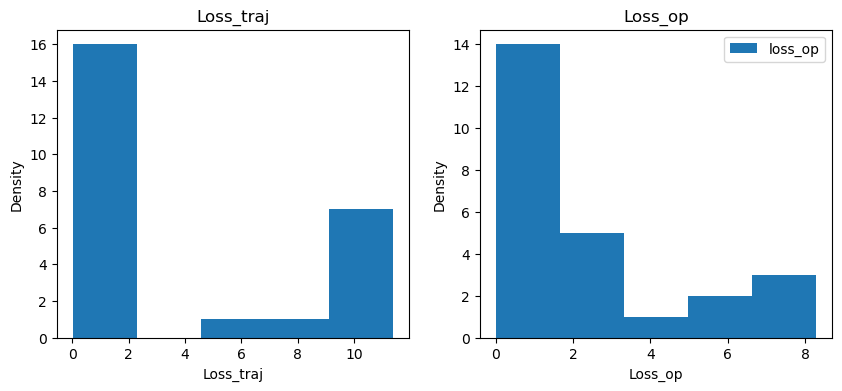

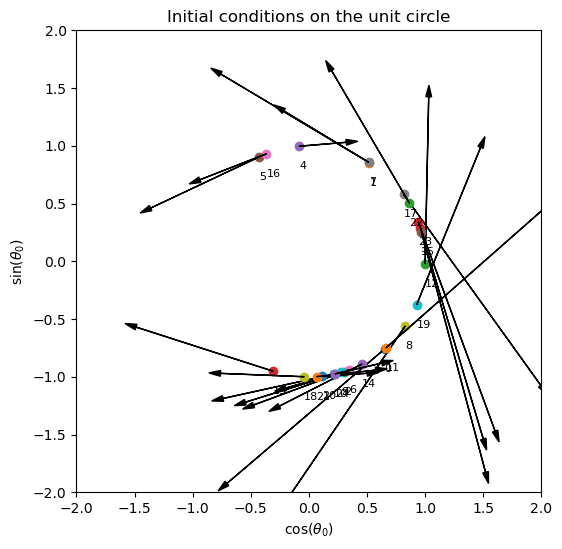

In [311]:
viz_CI_regimes(results)

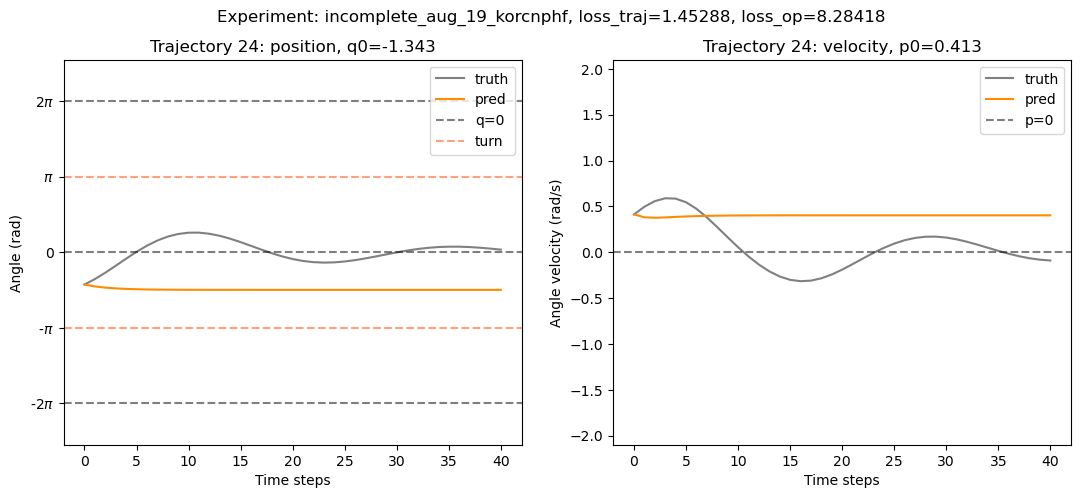

In [324]:
plot_trajectory(results, exp_name, 24)

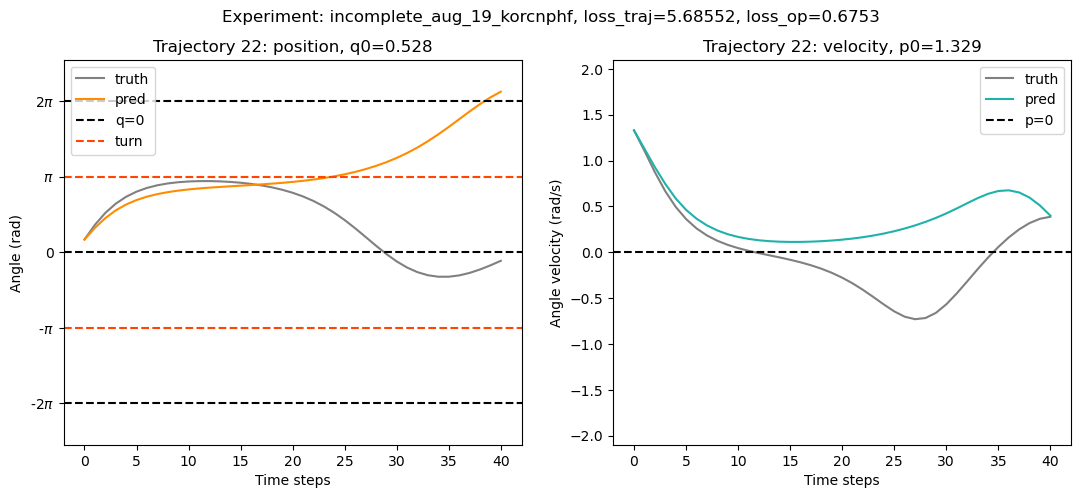

In [313]:
plot_trajectory(results, exp_name, 22)  

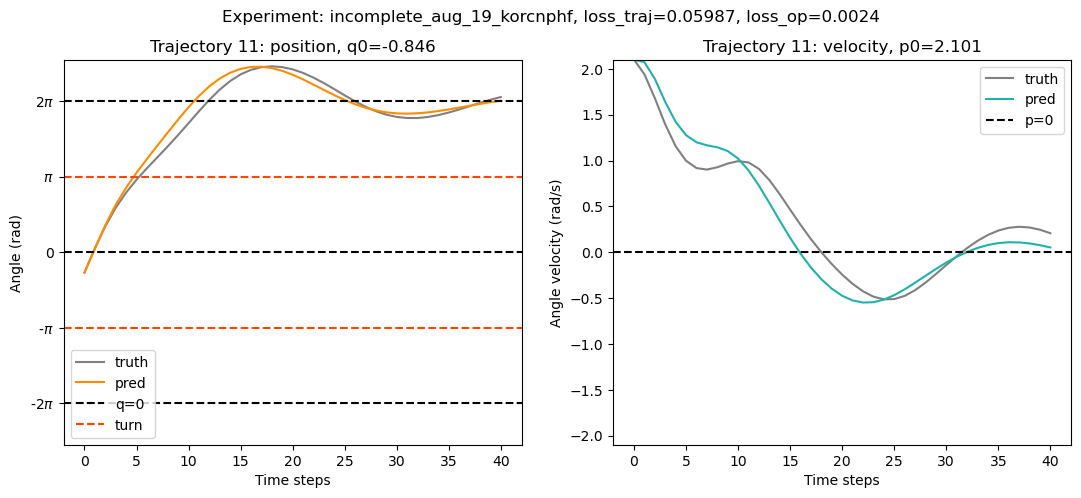

In [314]:
plot_trajectory(results, exp_name, 11)

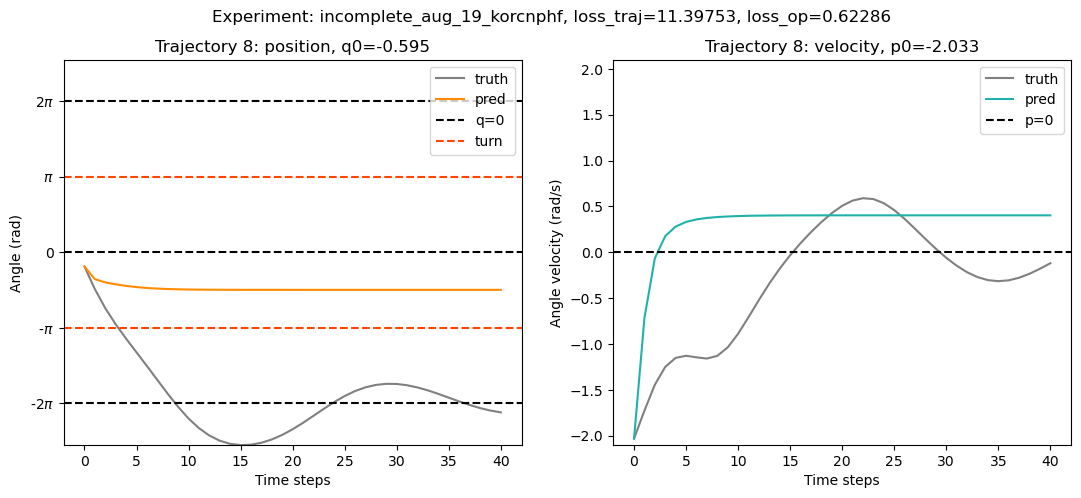

In [315]:
plot_trajectory(results, exp_name, 8)

# Final version of code
Jit corrected, 400 epochs

- SC1: complete_physics_26_f6dwvliv
- SC2: incomplete_aug_30_q5w7dej1
- SC2.2: incomplete_no_Fa_aug_28_riymbky6
- SC3: none_aug_24_of0iieil

Pour les SC2, avec min_op='l2', lambda_0=10, tau_2=100:
- SC2: incomplete_aug_34_lx8y2wmb


In [372]:
from datasets import * 
import os
path = 'data/sanity_checks2'
dataset_name = 'pendulum'
train, _,_ = init_dataloaders("pendulum", 'RK4', os.path.join(path, dataset_name))

for i, train_data in enumerate(train):
    print(train_data["states"].shape)

y0 = train_data["states"][:,:,0]
y0 = pd.DataFrame(y0, columns=["q0", "p0"])
y0

torch.Size([25, 2, 41])


,q0,p0
0,-1.334527,0.894015
1,-0.144654,-2.158659
2,0.262720,1.561437
3,1.402906,1.221938
4,1.519548,-1.305323
5,2.101425,-0.089342
6,1.486833,-0.771030
7,1.659655,1.451410
8,1.759936,-0.704725
9,-0.974419,-1.359348


In [375]:
def viz_losses_regimes(res, y0train):
    fig, ax = plt.subplots(1,1,figsize=(10, 15))
    delta=0.1
    # put index of traj above the point
    for i, txt in enumerate(res.index):
        ax.annotate(txt, (res["q0"][i], res["p0"][i]+ delta))
    # Scatter plot for left half (loss_traj)
    sc1 = ax.scatter(res["q0"], res["p0"], c=res["loss_traj"], cmap="viridis", marker=8, label="Loss Traj", linewidths=3)

    # Scatter plot for right half (loss_op)
    sc2 = ax.scatter(res["q0"], res["p0"], c=res["loss_op"], cmap="cool", marker=9, label="Loss Op", linewidths=3)

    # add train samples 
    plt.scatter(y0train["q0"], y0train["p0"], label="Train y0", color="black", marker="x")

    # Add colorbars
    cbar1 = plt.colorbar(sc1, ax=ax, label="Loss Traj (left)", orientation="horizontal")
    cbar2 = plt.colorbar(sc2, ax=ax, label="Loss Op (right)", orientation="horizontal")

    plt.title(f"Phase portrait of test initial conditions, colored by loss_traj")
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\dot{\theta}_0$")
    plt.legend()
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
    plt.show()
    

In [383]:
def plot_phase_trajectory(res, exp, index):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    y0 = np.array(res["states"][index])[:,0]
    # set y max
    ax.set_ylim([-8, 8])
    ax.set_ylim([-2.1,2.1])

    ax.set_title(f"Phase portrait {index}") 
    traj = res["states"][index]
    traj_pred = res["pred"][index]
    plt.plot(np.array(traj[0]), np.array(traj[1]), label="truth", color="gray")
    plt.plot(np.array(traj_pred[0]),np.array(traj_pred[1]), label="pred", color="darkorange")
    plt.xlabel("Angle (rad)")
    plt.ylabel("Angle velocity (rad/s)")
    plt.legend()
    plt.suptitle(f"Experiment: {exp}, loss_traj={round(res['loss_traj'][index],5)}, loss_op={round(res['loss_op'][index],5)}")
    plt.show()
    

In [508]:
def plot_Fp_Fa_out(res, index):
    # one index, after we plot for all
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    input = np.array(res["states"][index])
    q, p = input[:,0], input[:,1]
    output_fa = np.array(res["Fa"][index])
    output_fp = np.array(res["Fp"][index])
    # recover phase portrait
    ax[0][0].scatter(q,p,label="true phase portrait", color="black")
    ax[0][0].scatter(q, output_fp[:,0], color="red", label="Fp[0] ~ p")
    ax[0][0].scatter(q, output_fa[:,0], color="blue", label="Fa[0] ~ 0")
    ax[0][0].legend()
    ax[0][0].set_xlabel("q")
    ax[0][0].set_title("F[0] vs q, should be phase portrait")
    
    # recover p 
    ax[0][1].scatter(p,p, label="p = p", color="black")
    ax[0][1].scatter(p, output_fp[:,0], label="Fp[0] ~ p", color="red")
    ax[0][1].scatter(p, output_fa[:,0], label="Fa[0] ~ 0", color="blue")
    ax[0][1].legend()
    ax[0][1].set_xlabel("p")
    ax[0][1].set_title("F[0] vs p ~ y=p")

    # recover sinusoidal
    ax[1][0].scatter(q, -(2*jnp.pi/12)**2 * jnp.sin(q), label='truth', color="black")
    ax[1][0].scatter(q, output_fp[:,1], label='Fp[1] ~ sin', color="red")
    ax[1][0].scatter(q, output_fp[:,1]+ output_fa[:,1] + 0.2 * p, label=r'(Fp+Fa)[1] + $\alpha p$ ~ sin', color="purple")
    ax[1][0].legend()
    ax[1][0].set_xlabel("q")
    ax[1][0].set_title("F[1] vs q ~ sin(q)")

    # recover alpha
    ax[1][1].scatter(p, -0.2 * p, label='truth', color="black")
    ax[1][1].scatter(p, output_fa[:,1], label='Fa[1] ~ -0.2p', color="blue")
    ax[1][1].scatter(p, output_fp[:,1]+ ((2*jnp.pi/12)**2) * jnp.sin(q), color="red", label='Fp[1]+$\omega_0^2$ sin(q) ~ 0')
    ax[1][1].scatter(p, output_fp[:,1] + output_fa[:,1] + ((2*jnp.pi/12)**2) * jnp.sin(q), label=r"(Fa+Fp)[1]+ $\omega_0^2$ sin(q) ~ -$\alpha$*p", color="purple")
    ax[1][1].legend()
    ax[1][1].set_xlabel("p")
    ax[1][1].set_title(r"F[1] + $\omega_0^2 sin(q)$  ~ -$\alpha$*p")  
    fig.suptitle(f"Fp+Fa dynamics for trajectory {index}")
    plt.show()    


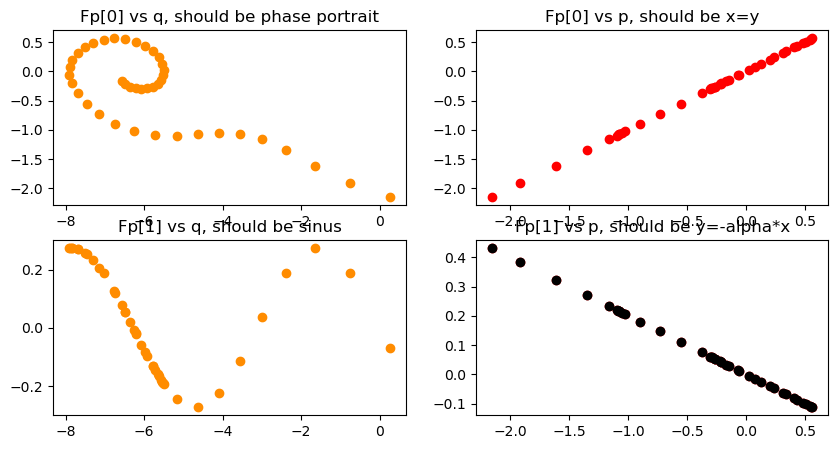

In [497]:
# complete physics for debug
def plot_Fp_out(res, index):
    # one index, after we plot for all
    fig, ax = plt.subplots(2, 2, figsize=(10, 5))
    input = np.array(res["states"][index])
    q, p = input[:,0], input[:,1]
    output_fa = np.array(res["Fa"][index])
    output_fp = np.array(res["Fp"][index])
    ax[0][0].scatter(q, output_fp[:,0], label="Fp[0] v q, should be phase portrait", color="darkorange")
    ax[0][1].scatter(p, output_fp[:,0], label="Fp[0] v p, should be x=y", color="red")
    ax[1][0].scatter(q, output_fp[:,1] + 0.2 * p, label='Fp[1] v q, should be sinusoidal', color="darkorange")
    ax[1][1].scatter(p, output_fp[:,1] + ((2*np.pi/12)**2) * np.sin(q), label="Fp[1] vs p, should be y=-alpha*x", color="red")
    ax[1][1].scatter(p, -0.2 *p, color="black", label="y=-alpha*x")
    ax[0][0].set_title("Fp[0] vs q, should be phase portrait")
    ax[0][1].set_title("Fp[0] vs p, should be x=y")
    ax[1][0].set_title("Fp[1] vs q, should be sinus")
    ax[1][1].set_title("Fp[1] vs p, should be y=-alpha*x")


    plt.show()    

path_sc1_fa = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_26_f6dwvliv/model_2.107e-08_Fa.json"
results_sc1_fa = pd.read_json(path_sc1_fa).T
results_sc1_fa
plot_Fp_out(results_sc1_fa, 15)



## SC1 
Final omega: 0.2741805911064148, Final alpha: 0.19998720288276672

In [316]:
path_sc1 = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_26_f6dwvliv/model_2.107e-08.json"
results_sc1, exp_name_sc1, val_loss_sc1 = load_results(path_sc1)
exp_name_sc1, val_loss_sc1

('complete_physics_26_f6dwvliv', 2.107)

In [317]:
results_sc1

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682551622390747, -2....",0.0,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403507828712463, 1.68330...",0.0,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.656402707099914, -1.9...",0.0,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.615477681159973, -1....",0.0,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.428601622581482, 1.1597...",0.0,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.477983951568603, 2.8583...",0.0,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.601447343826294, -1.8...",0.0,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.705878734588623, 2.2544...",0.0,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.5363882780075069, -2...",0.0,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.49467384815216, -1.61...",0.0,0.0,-1.292473,-0.493132


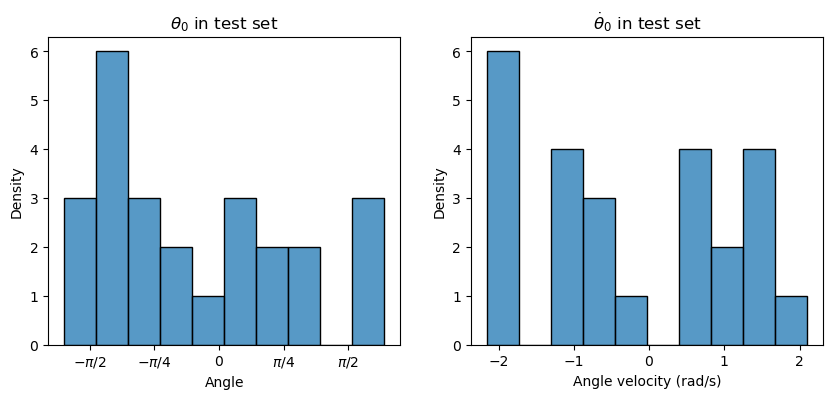

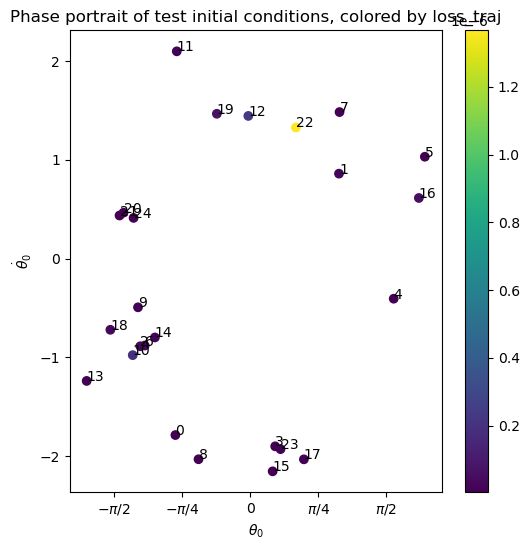

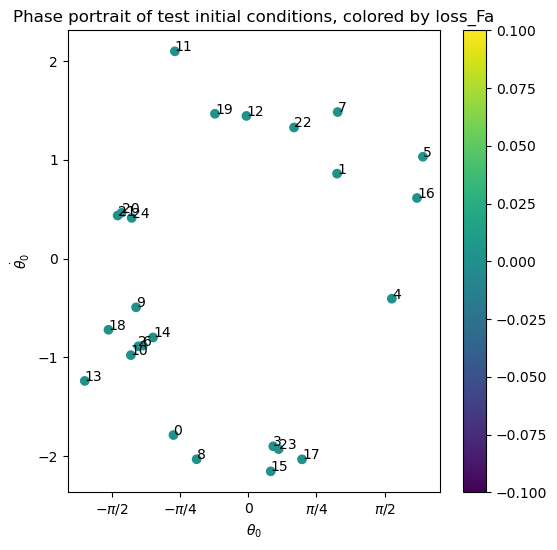

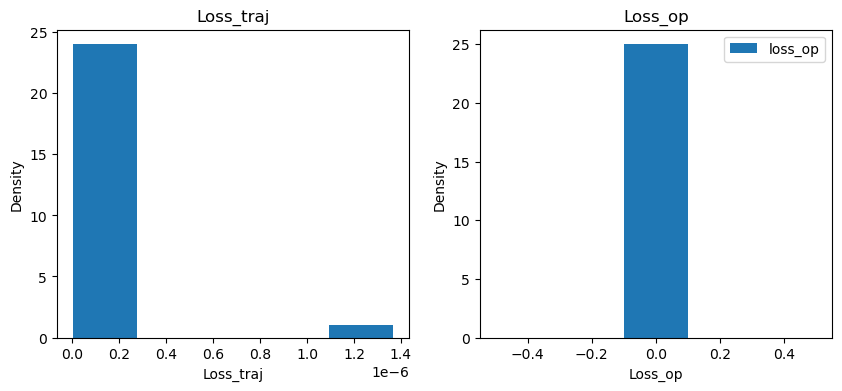

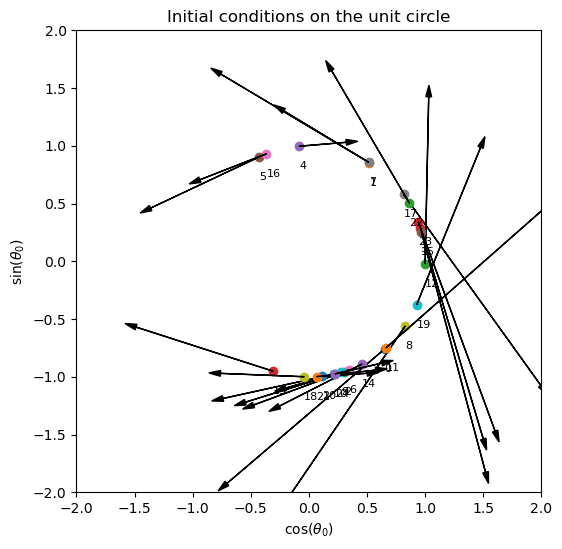

In [327]:
viz_CI_regimes(results_sc1, type="test")

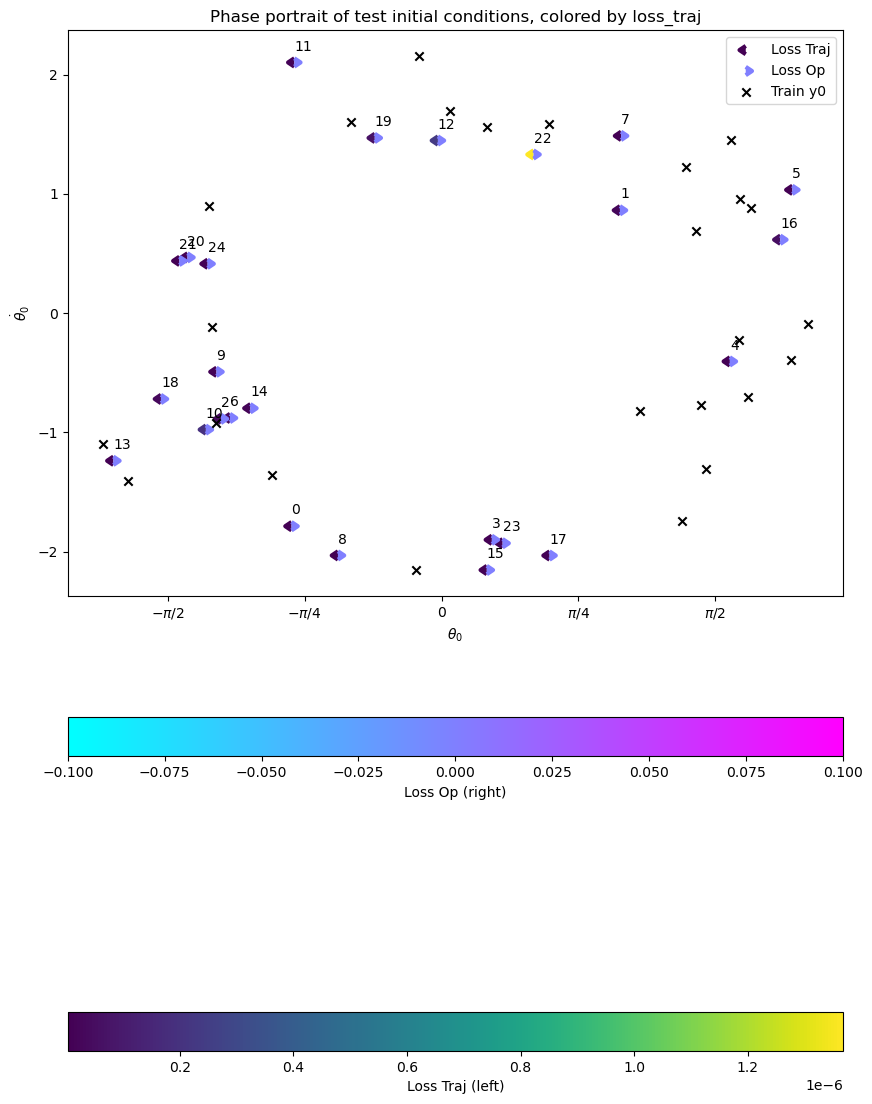

In [376]:
viz_losses_regimes(results_sc1, y0)

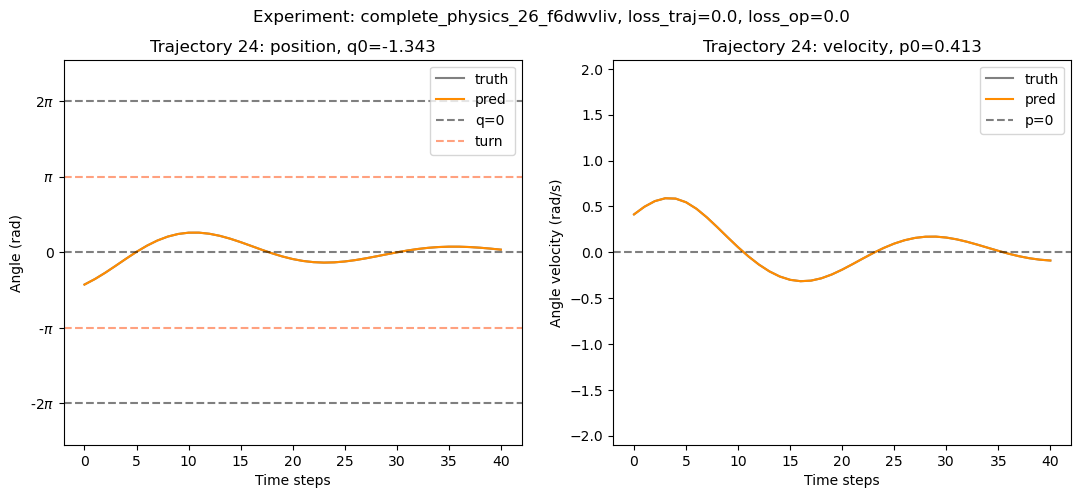

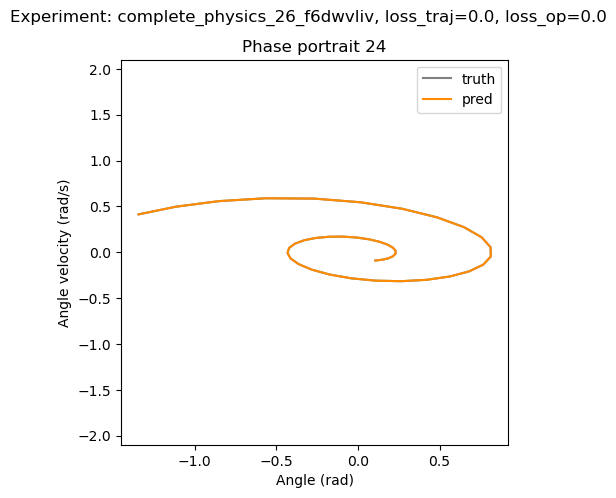

(None, None)

In [384]:
plot_trajectory(results_sc1, exp_name_sc1, 24), plot_phase_trajectory(results_sc1, exp_name_sc1, 24)

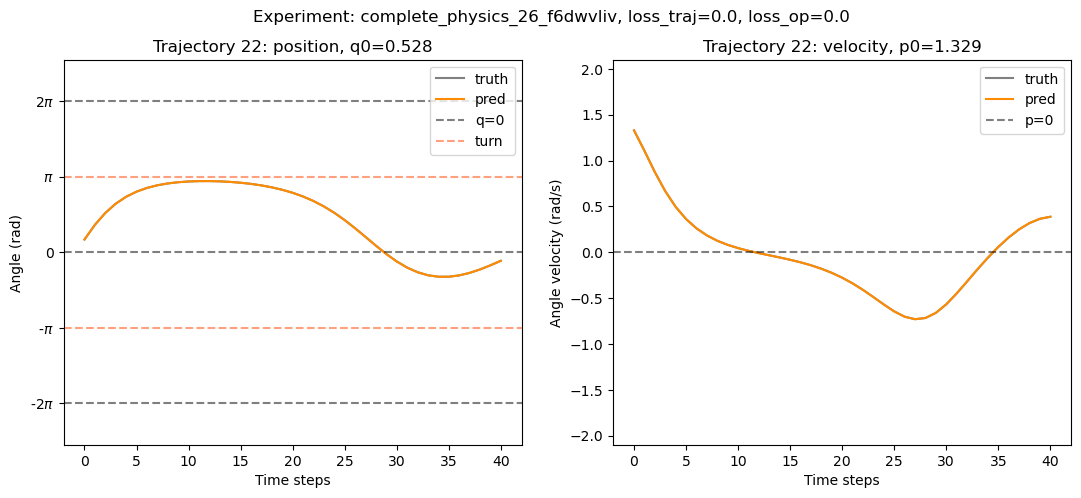

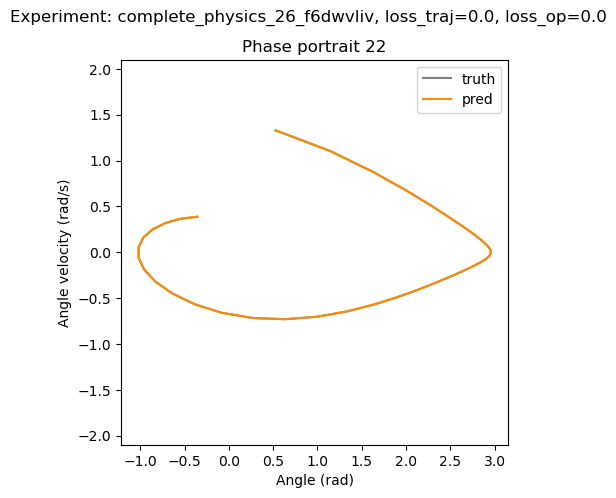

(None, None)

In [386]:
plot_trajectory(results_sc1, exp_name_sc1, 22), plot_phase_trajectory(results_sc1, exp_name_sc1, 22)

## SC2
Final omega: 0.21297499537467957, Final alpha: 0.0

In [370]:
path_sc2 = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_30_q5w7dej1/model_2.017e+00.json"
results_sc2, exp_name_sc2, val_loss_sc2 = load_results(path_sc2)
exp_name_sc2, val_loss_sc2

('incomplete_aug_30_q5w7dej1', 2.017)

In [391]:
results_sc2

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.617866516113281, -2....",0.711065,0.033757,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.322588324546814, 1.56581...",0.622355,1.164388,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.663885354995727, -1.9...",2.619721,0.67526,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.5882192850112911, -1...",0.621528,0.033912,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.326478719711303, 0.9668...",0.641329,2.4604,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.445233106613159, 2.8132...",0.047546,0.000842,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.614874839782714, -1.9...",2.177887,0.811577,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.672050714492797, 2.2272...",0.031738,0.001379,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.462558984756469, -2....",0.816079,0.034698,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.544344305992126, -1.7...",0.925543,2.439538,-1.292473,-0.493132


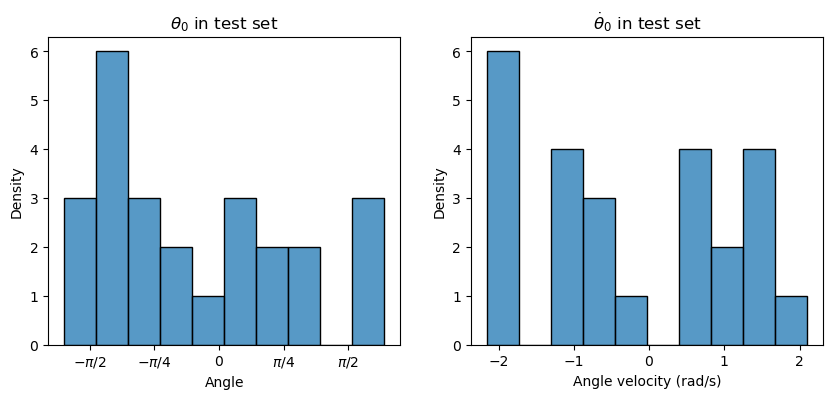

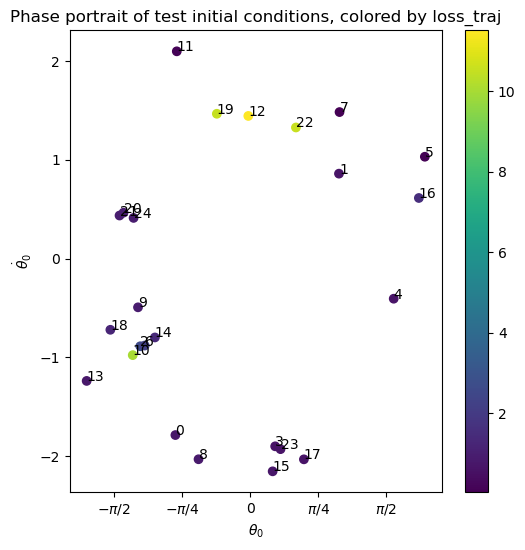

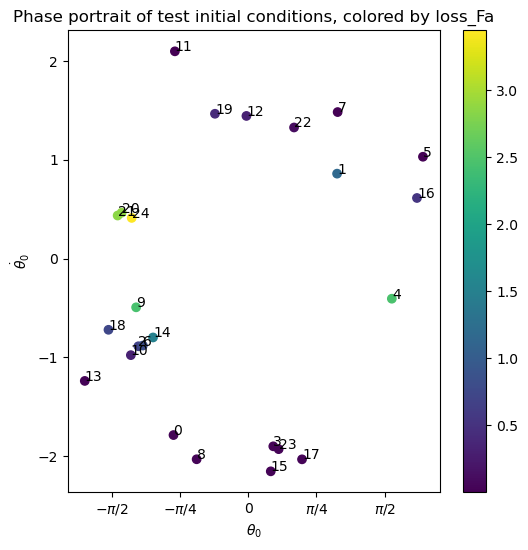

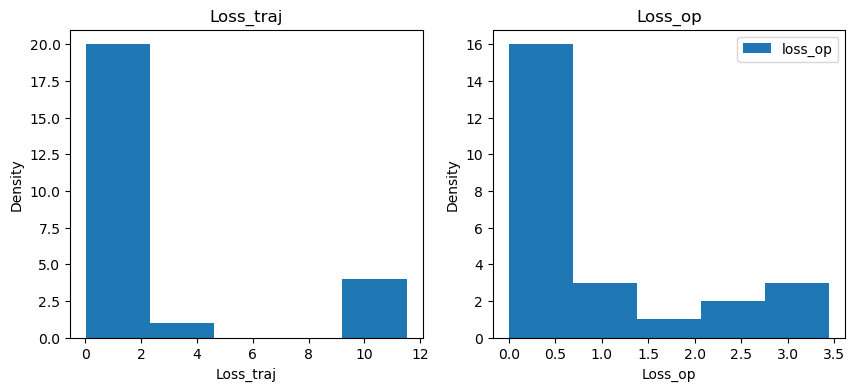

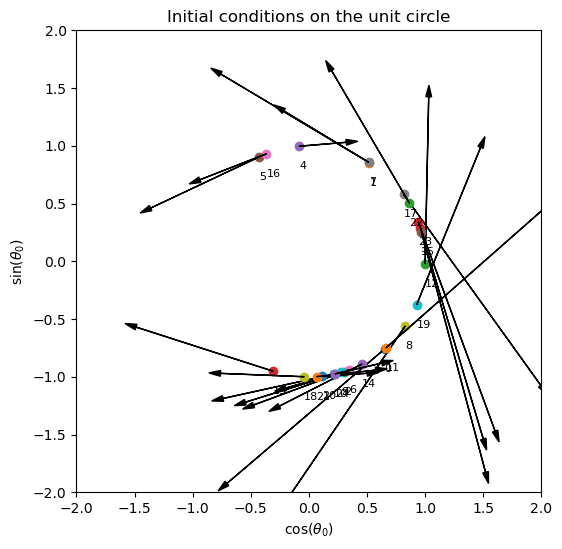

In [390]:
viz_CI_regimes(results_sc2)

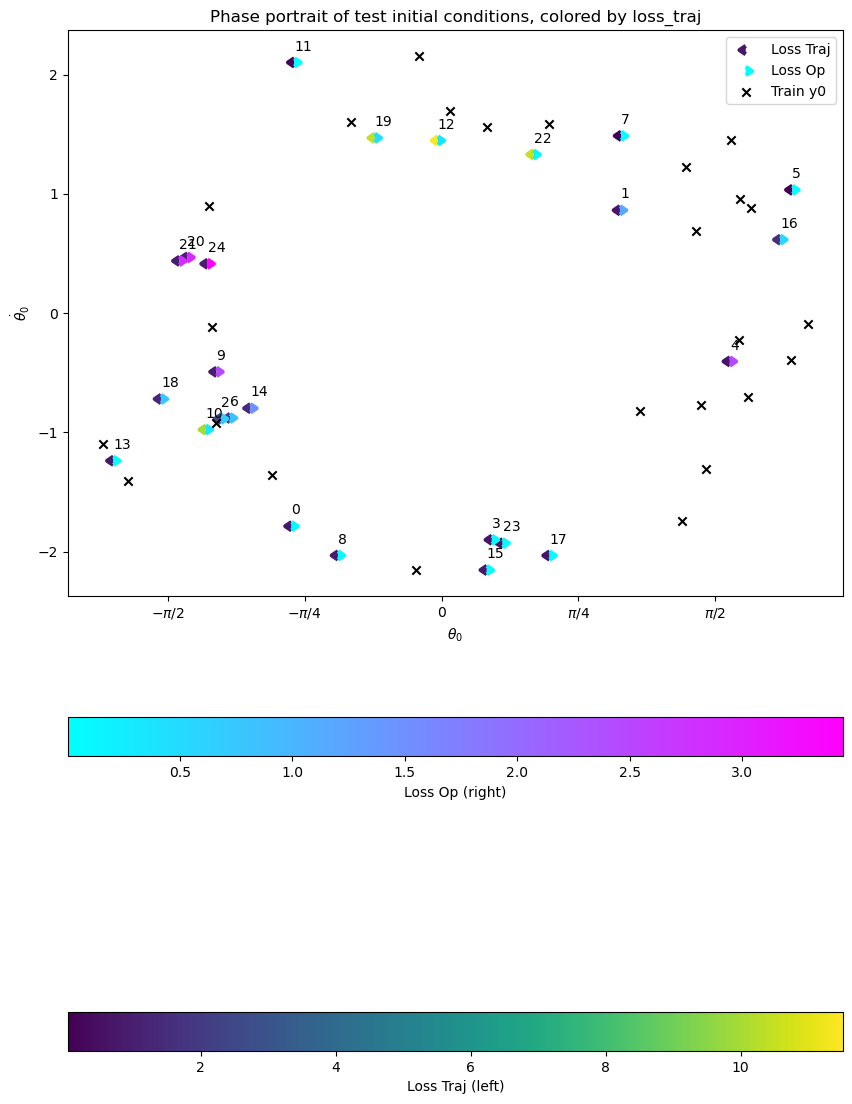

In [378]:
viz_losses_regimes(results_sc2, y0)

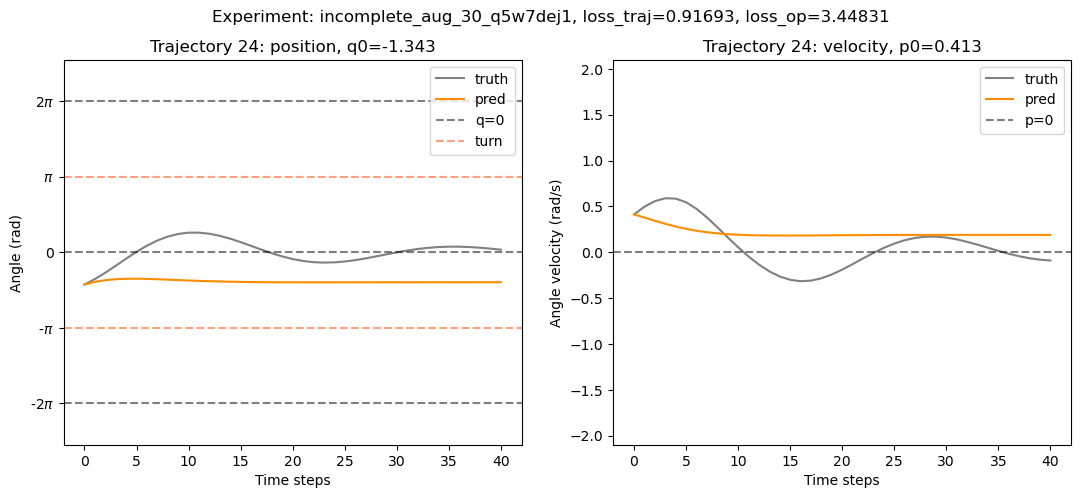

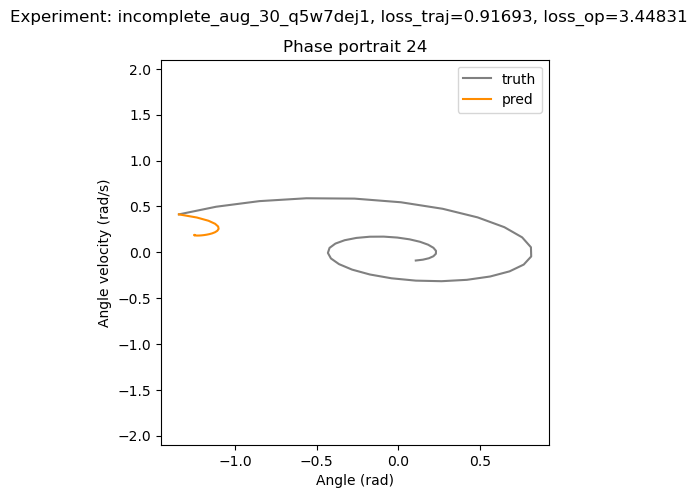

(None, None)

In [388]:
plot_trajectory(results_sc2, exp_name_sc2, 24), plot_phase_trajectory(results_sc2, exp_name_sc2, 24)

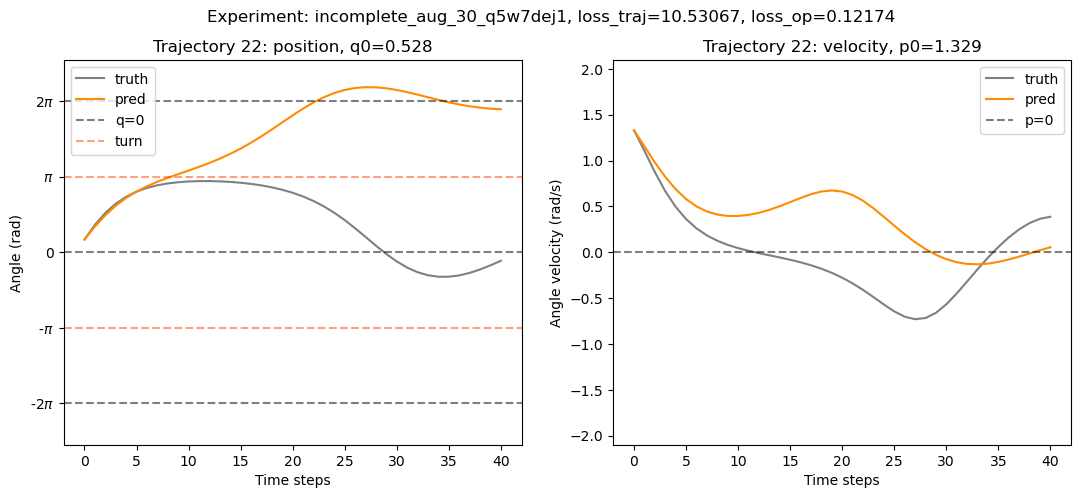

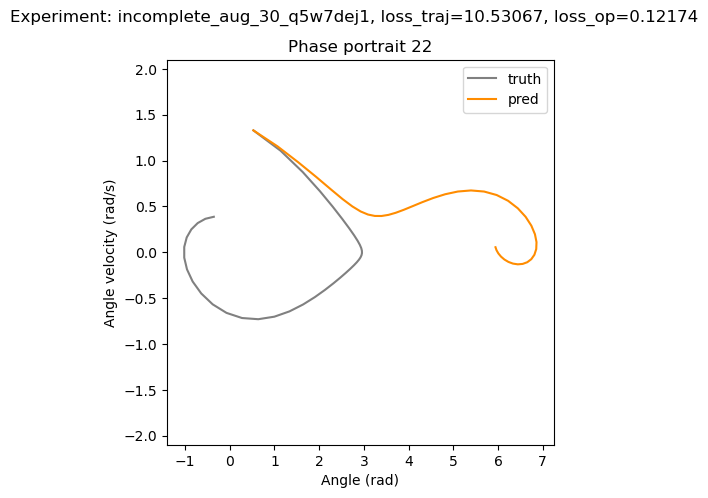

(None, None)

In [389]:
plot_trajectory(results_sc2, exp_name_sc2, 22), plot_phase_trajectory(results_sc2, exp_name_sc2, 22)

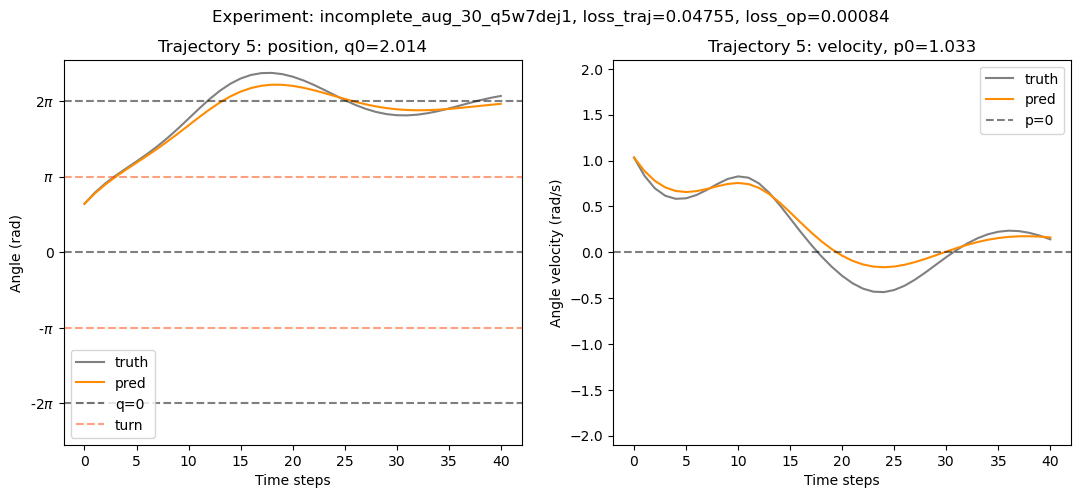

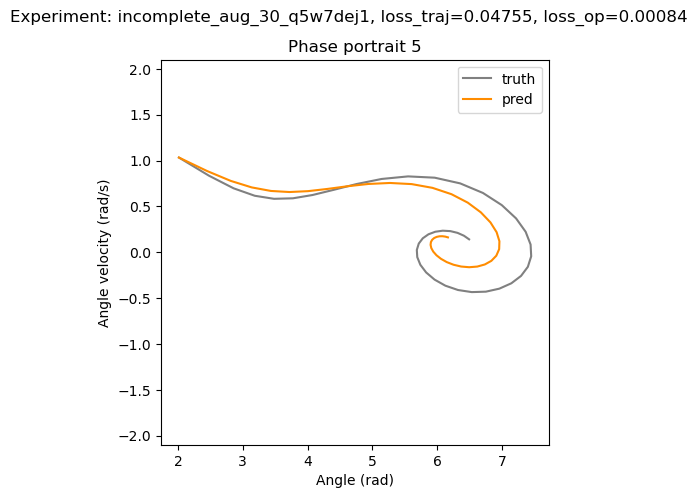

(None, None)

In [392]:
plot_trajectory(results_sc2, exp_name_sc2, 5), plot_phase_trajectory(results_sc2, exp_name_sc2, 5)

In [501]:
results_sc2_fa = pd.read_json("/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_30_q5w7dej1/model_2.017e+00_Fa.json").T

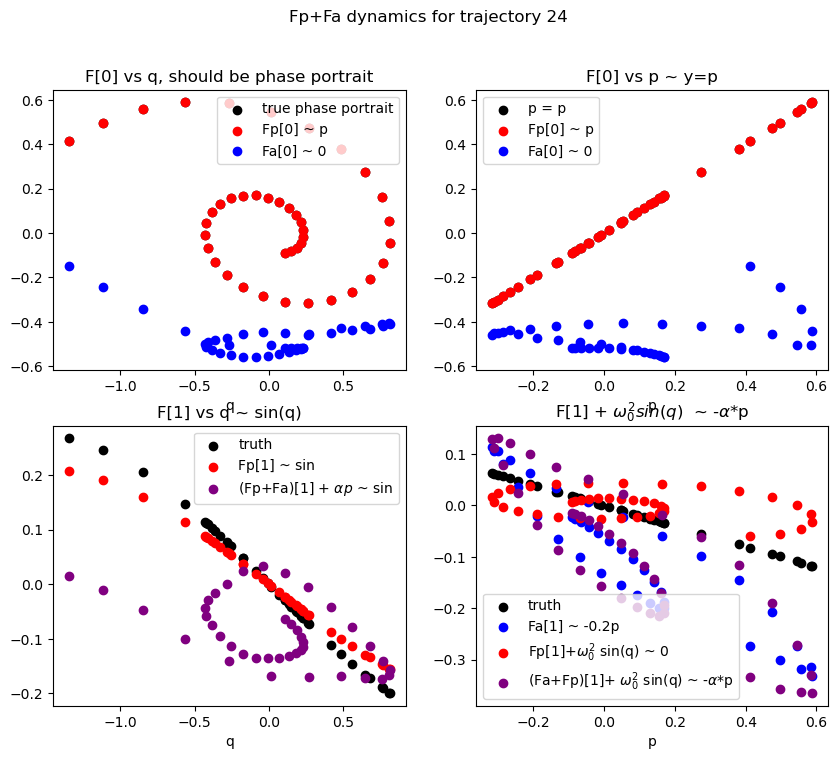

In [509]:
plot_Fp_Fa_out(results_sc2_fa, 24)

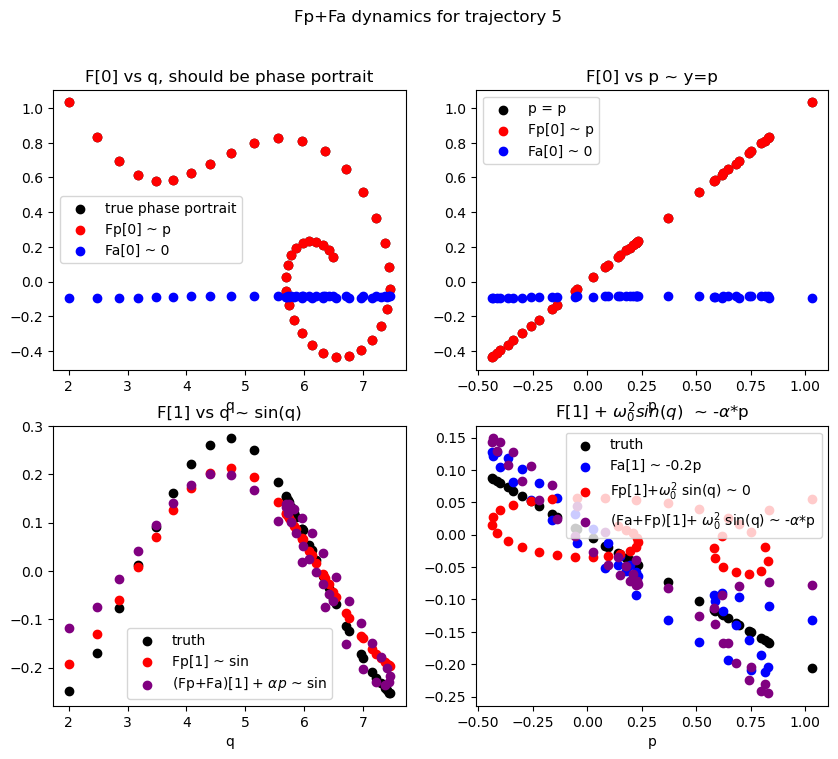

In [504]:
plot_Fp_Fa_out(results_sc2_fa, 5)

## SC2: min_op=l2, $\lambda_0=10$, $\tau_2=100$
Final omega: 0.2598634362220764, Final alpha: 0.0
Loss_op = 1.1e-2

In [510]:
path_sc2_l2_opt = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_34_lx8y2wmb/model_4.318e-03.json"
results_sc2_l2_opt, exp_name_sc2_l2_opt, val_loss_sc2_l2_opt = load_results(path_sc2_l2_opt)
exp_name_sc2_l2_opt, val_loss_sc2_l2_opt

('incomplete_aug_34_lx8y2wmb', 4.318)

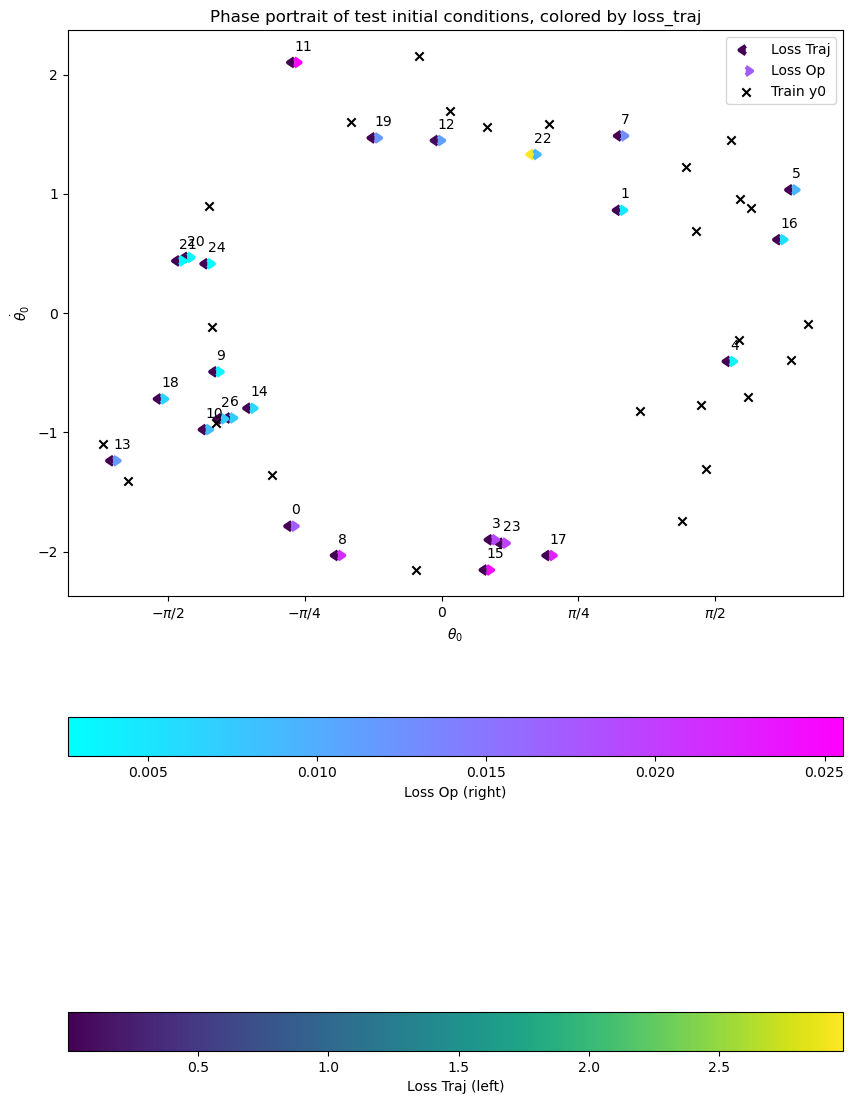

In [511]:
viz_losses_regimes(results_sc2_l2_opt, y0)

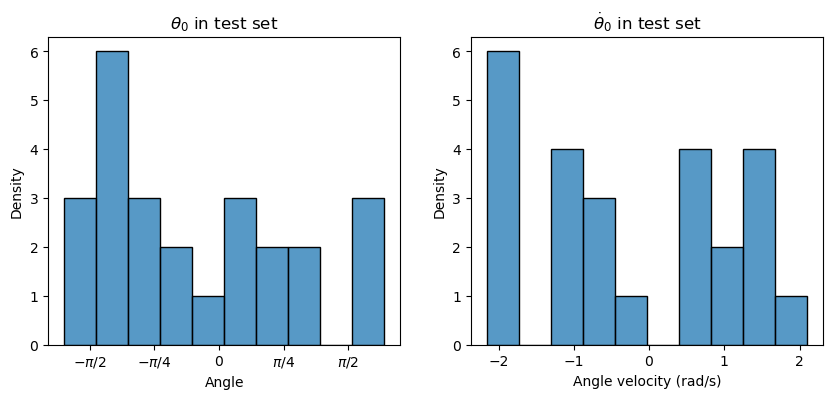

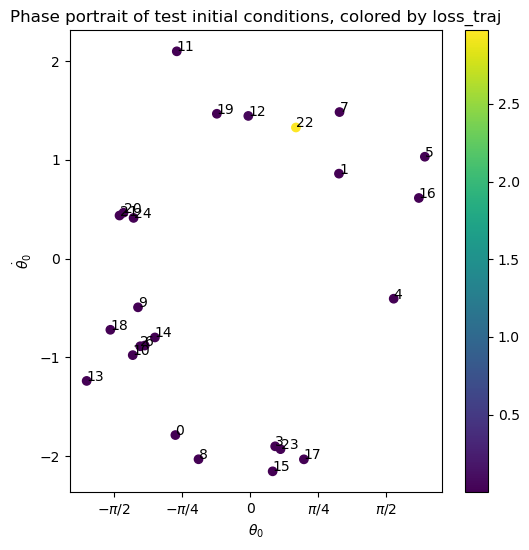

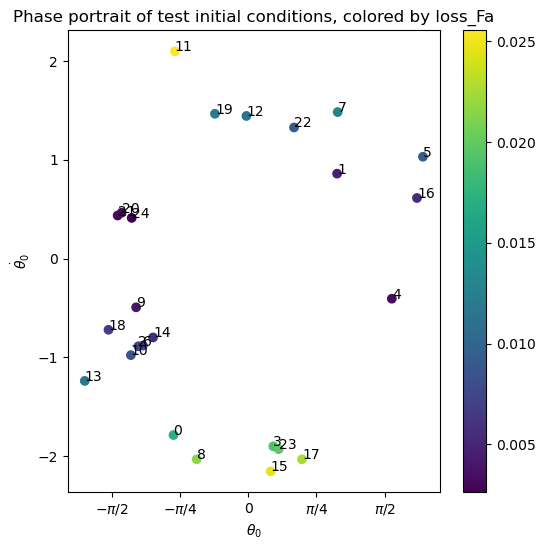

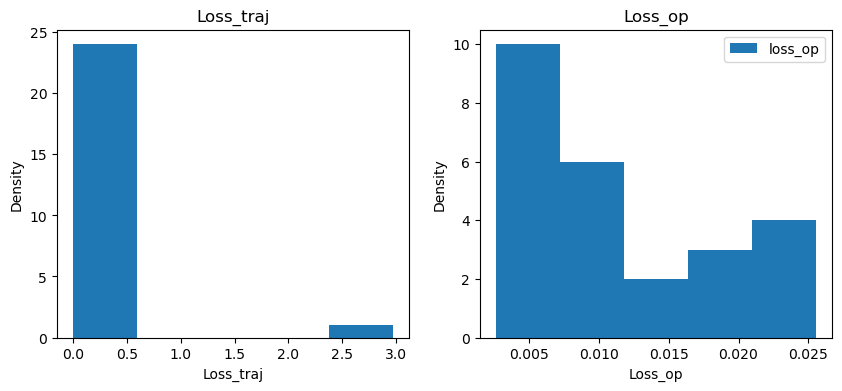

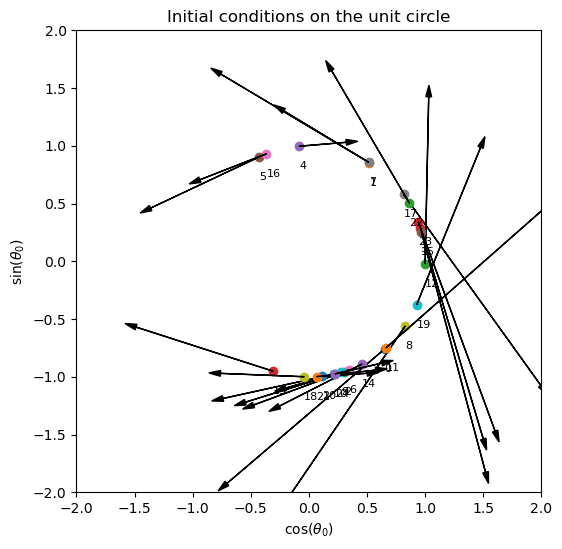

In [512]:
viz_CI_regimes(results_sc2_l2_opt)

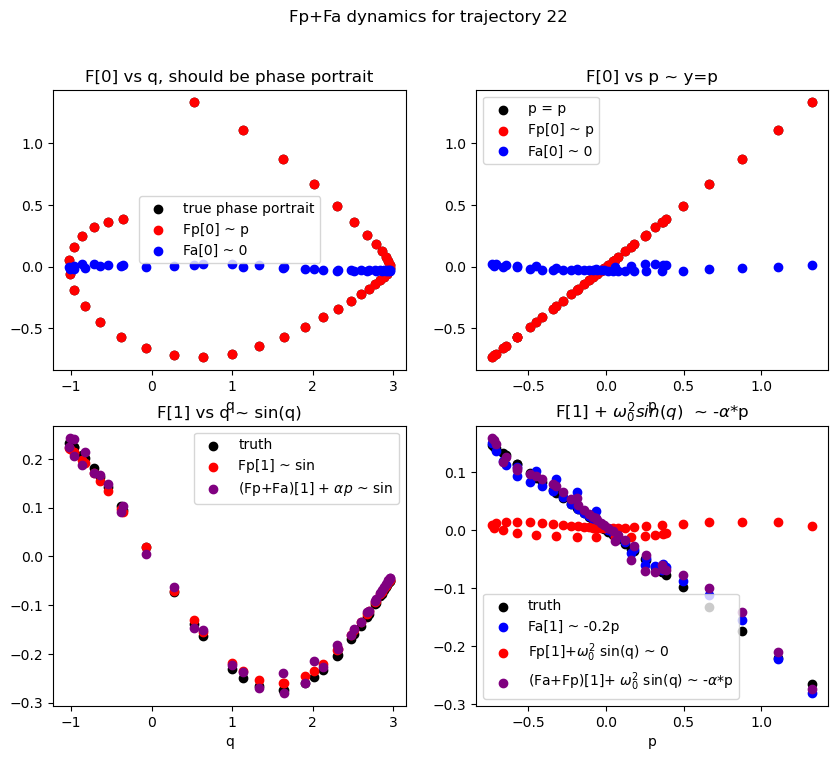

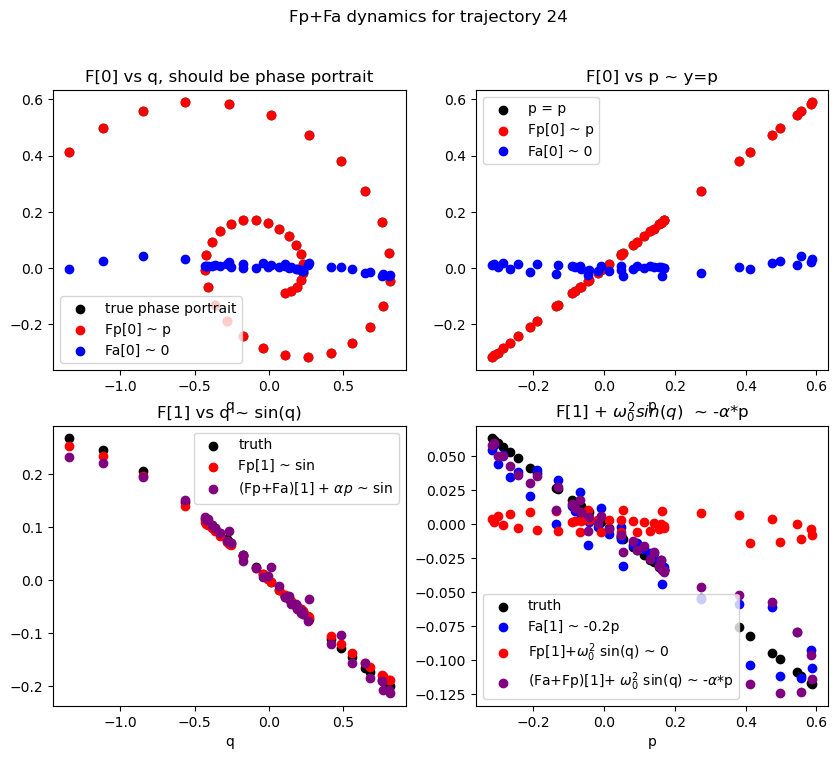

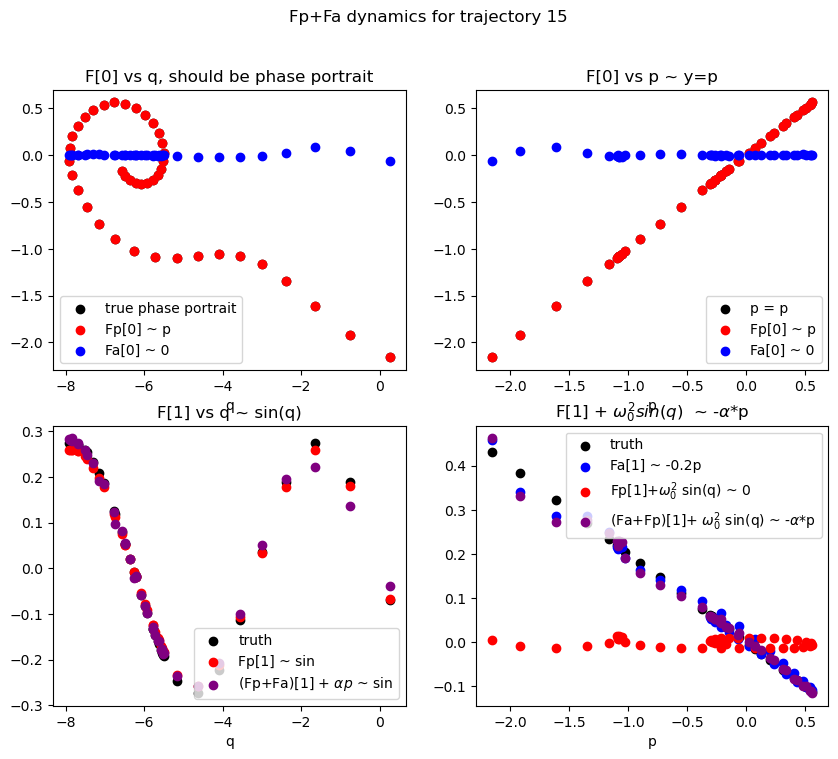

In [513]:
path_sc2_l2_opt_fa = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_34_lx8y2wmb/model_4.318e-03_Fa.json"
results_sc2_l2_opt_fa = pd.read_json(path_sc2_l2_opt_fa).T
plot_Fp_Fa_out(results_sc2_l2_opt_fa, 22)
plot_Fp_Fa_out(results_sc2_l2_opt_fa, 24)
plot_Fp_Fa_out(results_sc2_l2_opt_fa, 15)

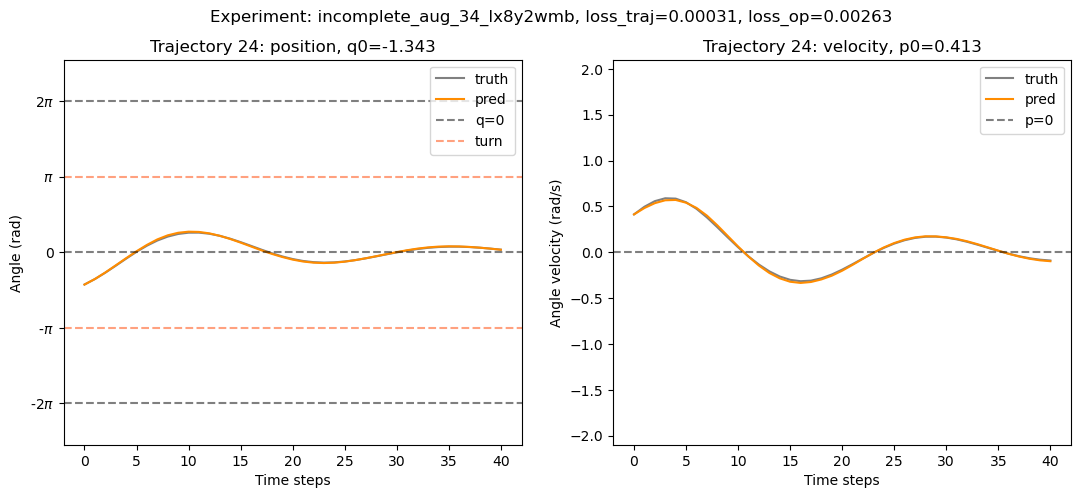

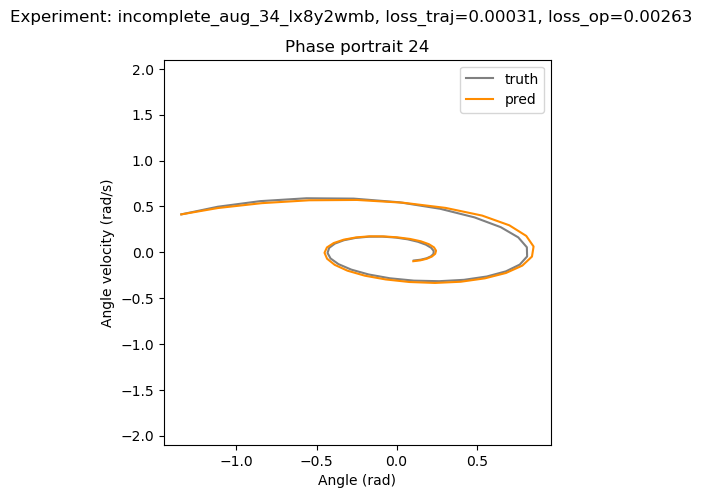

(None, None)

In [514]:
plot_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 24), plot_phase_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 24)

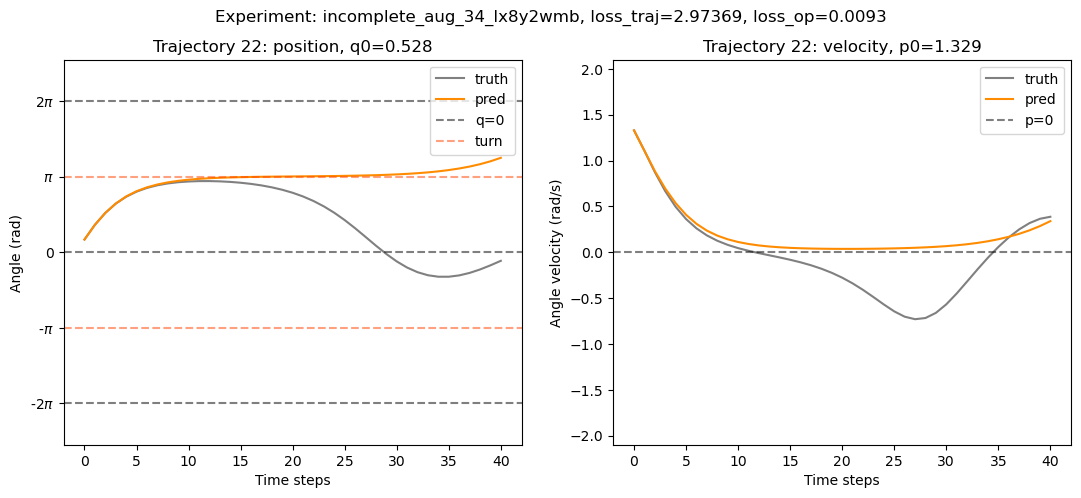

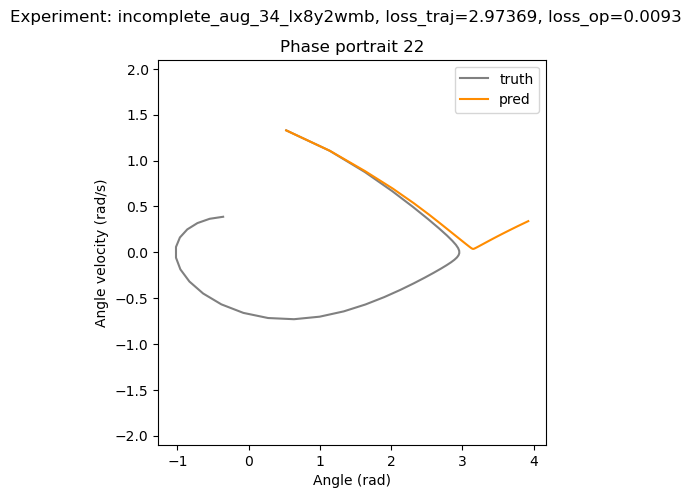

(None, None)

In [515]:
plot_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 22), plot_phase_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 22)

## SC2.2
Final omega: 0.2089155912399292, Final alpha: 0.0
Loss_op = 9.9e-03

In [332]:
path_sc22 = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_no_Fa_aug_28_riymbky6/model_5.693e-03.json"
results_sc22, exp_name_sc22, val_loss_sc22 = load_results(path_sc22)
exp_name_sc22, val_loss_sc22

('incomplete_no_Fa_aug_28_riymbky6', 5.693)

In [516]:
results_sc22["loss_op"].mean()

0.00990516677033112

In [ ]:
results_sc22_fa = pd.read_json("/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_no_Fa_aug_28_riymbky6/model_5.693e-03_Fa.json").T

In [495]:
results_sc22

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.593319177627563, -2....",0.001112,0.002196,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.39506983757019, 1.665999...",0.000269,0.015323,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.654339671134948, -1.9...",0.000358,0.012543,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.5541028976440431, -1...",0.004275,0.003332,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.421083211898803, 1.1506...",0.000265,0.015898,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.470595836639404, 2.8466...",0.000748,0.000727,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.598467230796814, -1.8...",0.000377,0.013109,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.705742359161377, 2.2512...",0.000345,0.001984,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.427940368652343, -2....",0.001998,0.002563,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.50156569480896, -1.62...",0.000359,0.01811,-1.292473,-0.493132


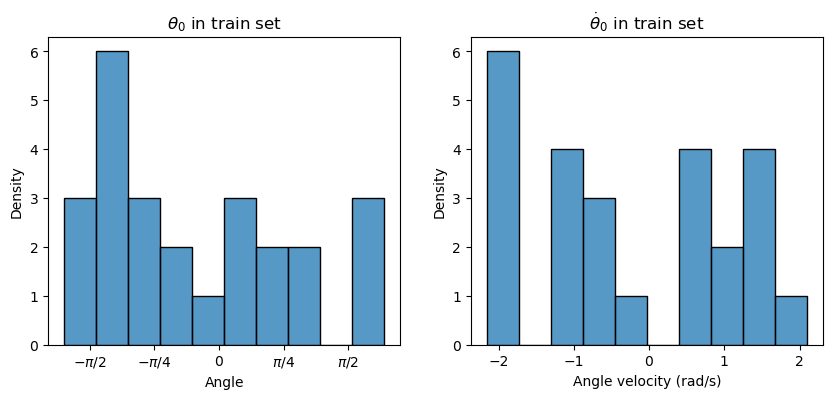

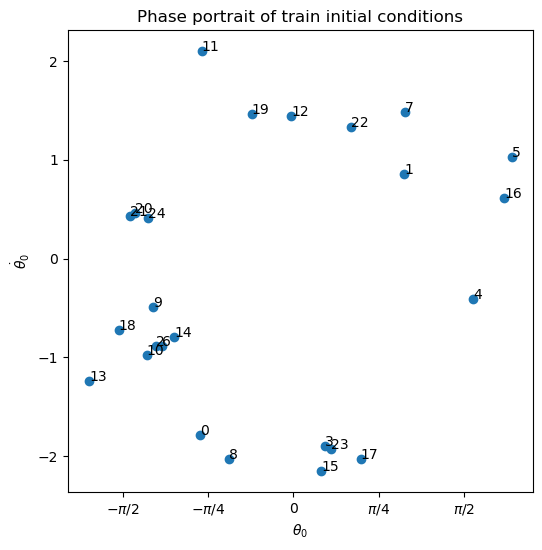

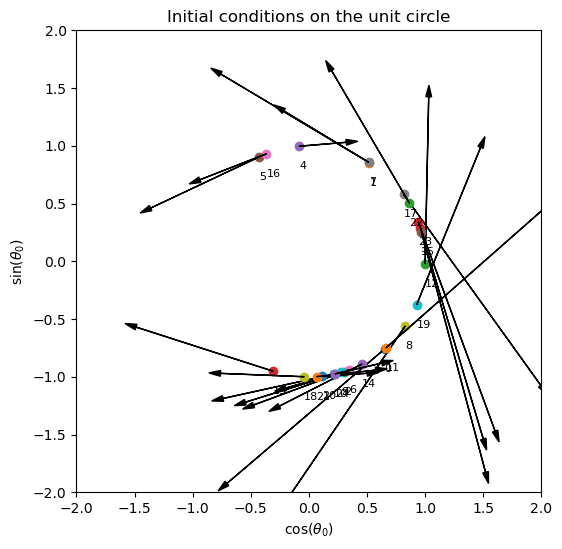

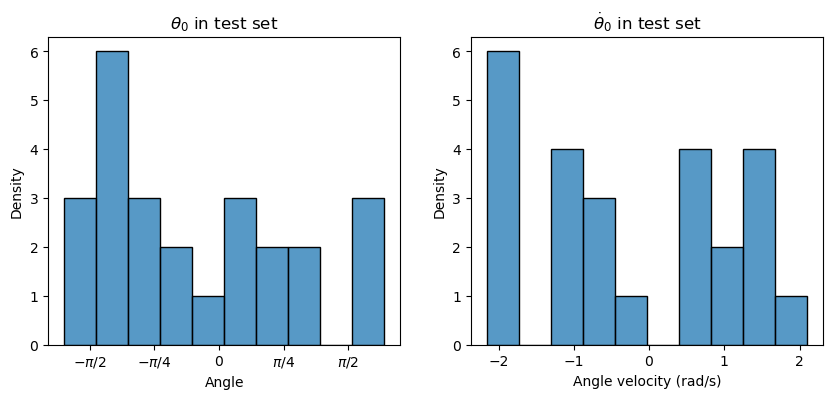

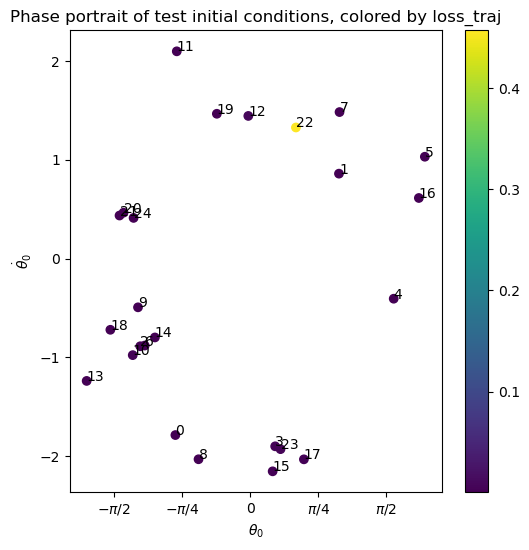

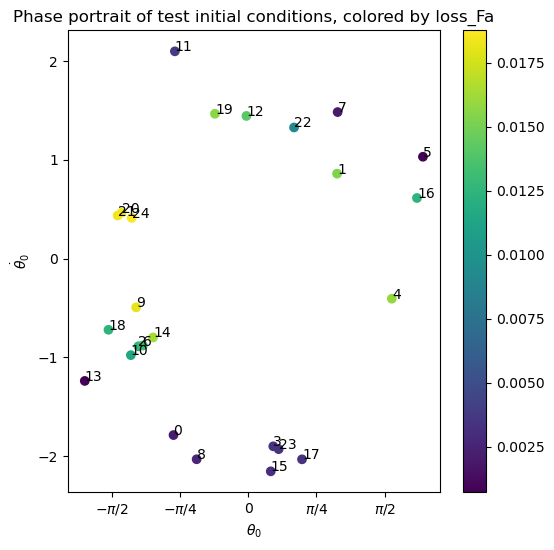

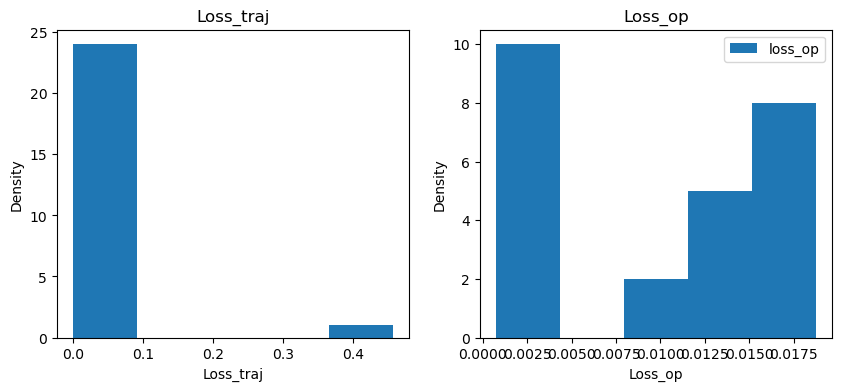

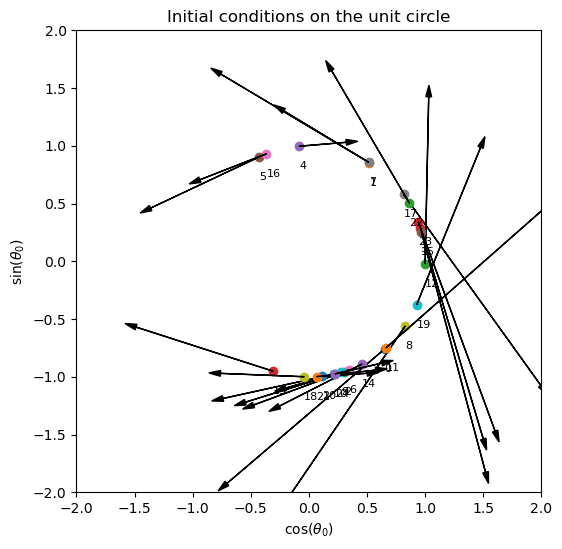

In [333]:
viz_CI_regimes(results_sc22, "train")
viz_CI_regimes(results_sc22, "test")

In [343]:
results_sc22_without22 = results_sc22.drop(22)
results_sc22_without22

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.593319177627563, -2....",0.001112,0.002196,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.39506983757019, 1.665999...",0.000269,0.015323,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.654339671134948, -1.9...",0.000358,0.012543,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.5541028976440431, -1...",0.004275,0.003332,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.421083211898803, 1.1506...",0.000265,0.015898,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.470595836639404, 2.8466...",0.000748,0.000727,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.598467230796814, -1.8...",0.000377,0.013109,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.705742359161377, 2.2512...",0.000345,0.001984,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.427940368652343, -2....",0.001998,0.002563,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.50156569480896, -1.62...",0.000359,0.01811,-1.292473,-0.493132


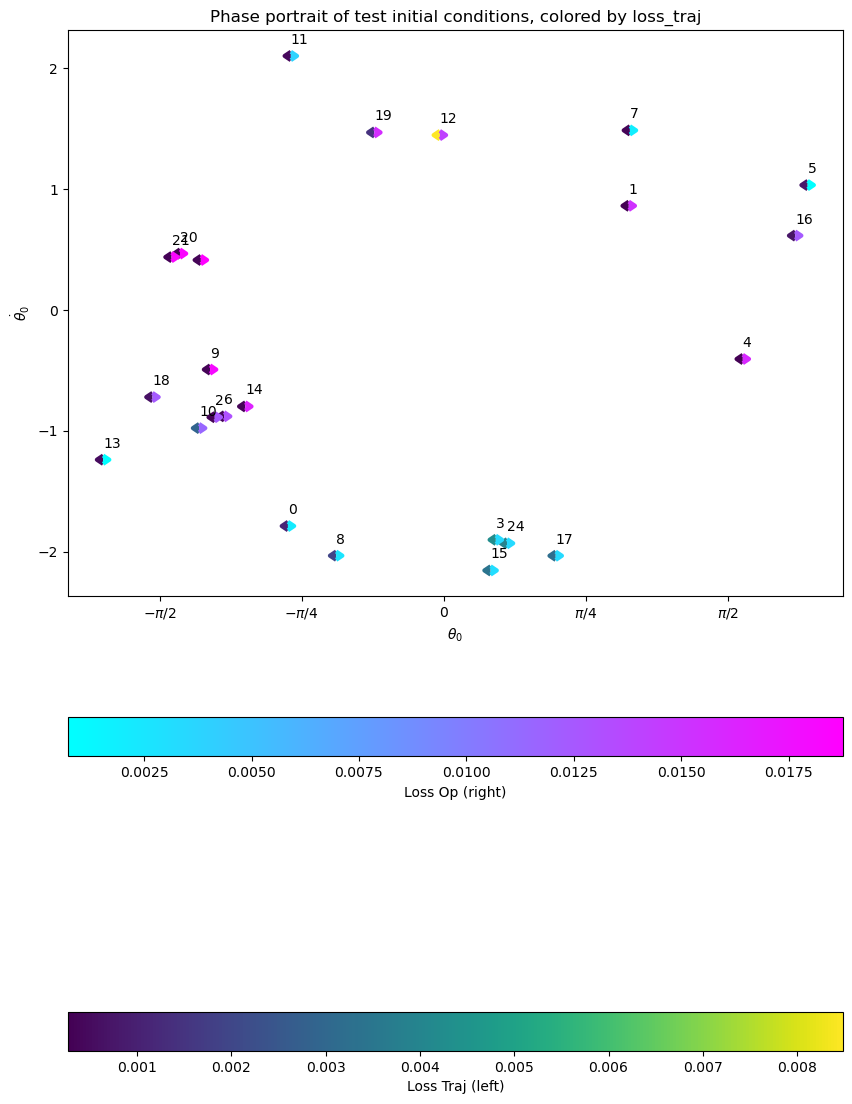

In [367]:
res = results_sc22_without22
type="test"
fig, ax = plt.subplots(1,1,figsize=(10, 15))
delta=0.1
# put index of traj above the point
for i, txt in enumerate(res.index):
    if i == 22:
        pass
    else:
        ax.annotate(txt, (res["q0"][i], res["p0"][i]+ delta))
# half circle with loss traj and other loss op
#plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_traj"], cmap="viridis")
# do same with 2 metrics on same scatter
# Scatter plot for left half (loss_traj)
sc1 = ax.scatter(res["q0"], res["p0"], c=res["loss_traj"], cmap="viridis", marker=8, label="Loss Traj", linewidths=3)

# Scatter plot for right half (loss_op)
sc2 = ax.scatter(res["q0"], res["p0"], c=res["loss_op"], cmap="cool", marker=9, label="Loss Op", linewidths=3)

# Add colorbars
cbar1 = plt.colorbar(sc1, ax=ax, label="Loss Traj (left)", orientation="horizontal")
cbar2 = plt.colorbar(sc2, ax=ax, label="Loss Op (right)", orientation="horizontal")

plt.title(f"Phase portrait of {type} initial conditions, colored by loss_traj")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\dot{\theta}_0$")
ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
plt.show()

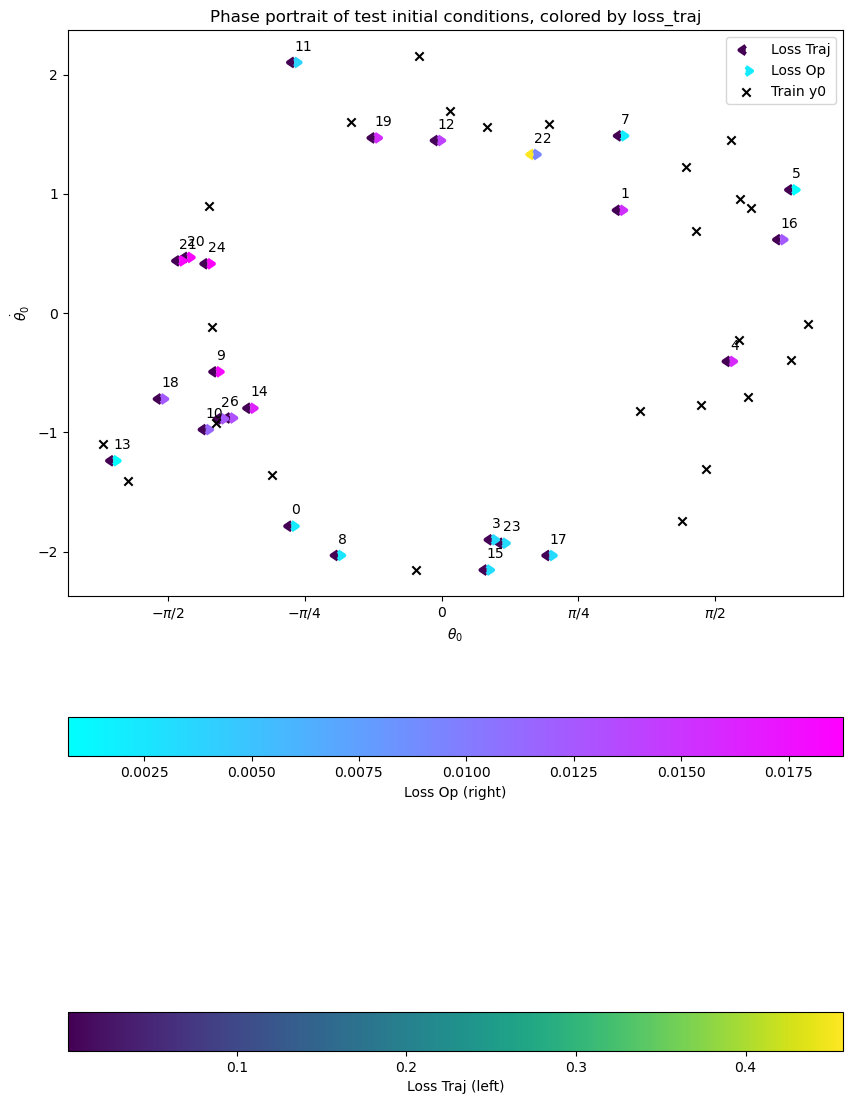

In [379]:
viz_losses_regimes(results_sc22, y0)

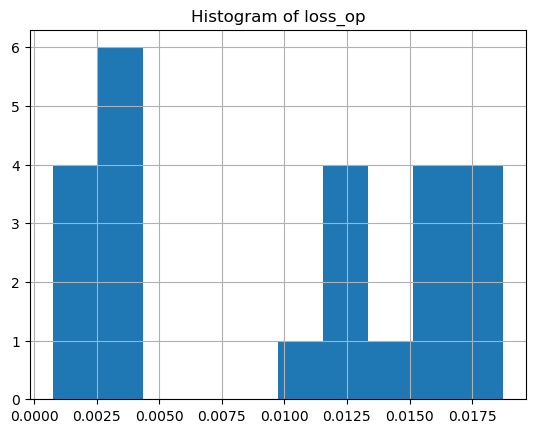

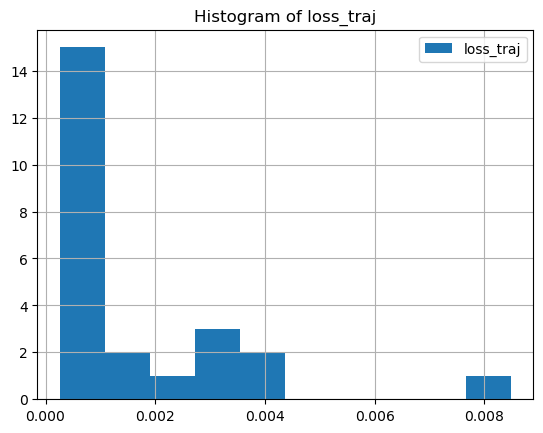

In [341]:
results_sc22_without22["loss_op"].hist(label="loss_op")
plt.title("Histogram of loss_op")
plt.show()
plt.figure()
results_sc22_without22["loss_traj"].hist(label="loss_traj")
plt.title("Histogram of loss_traj")
plt.legend()

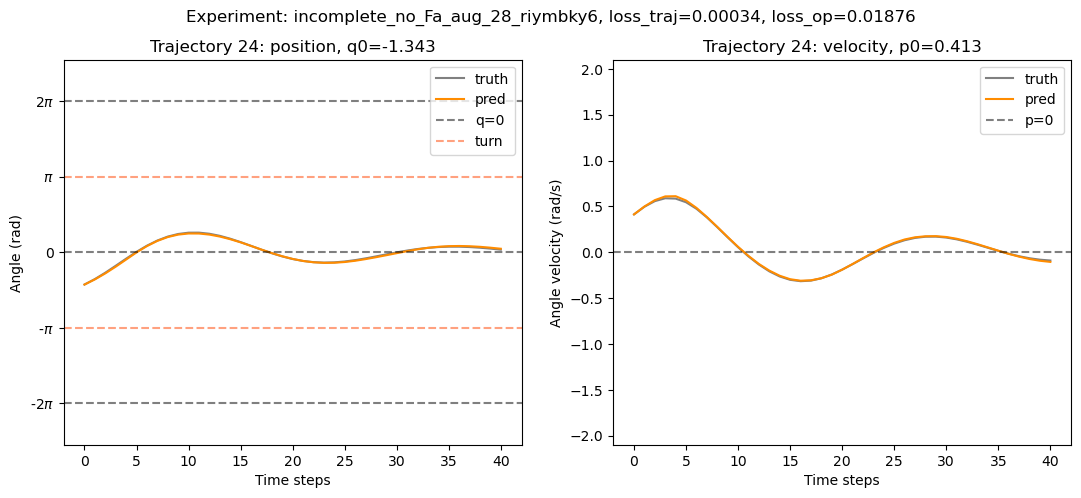

In [334]:
plot_trajectory(results_sc22, exp_name_sc22, 24)

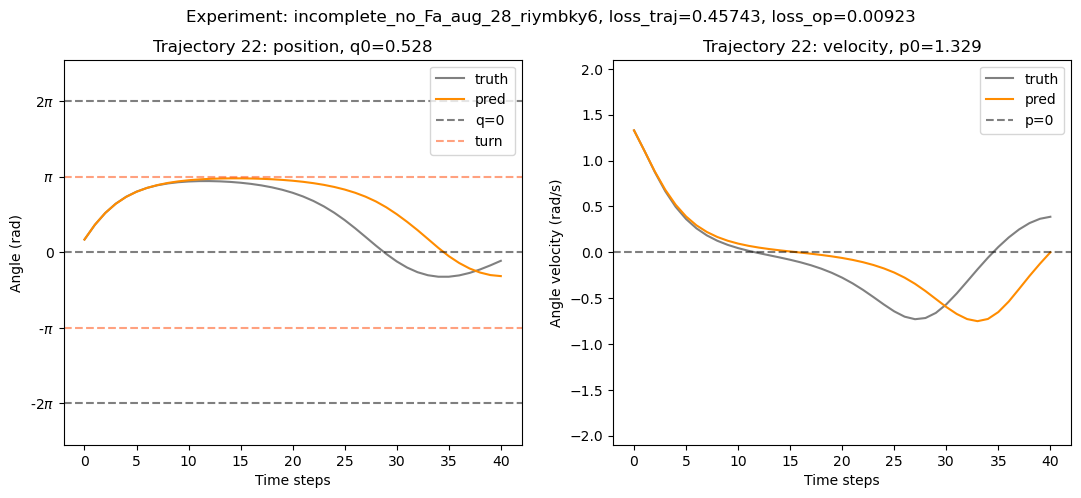

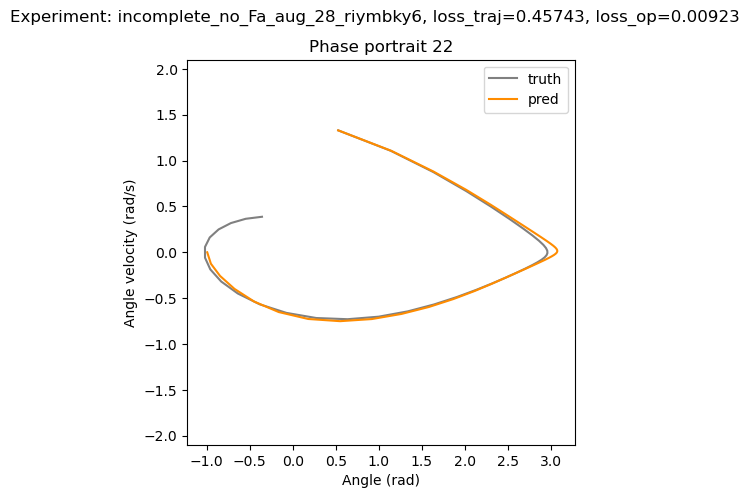

(None, None)

In [387]:
plot_trajectory(results_sc22, exp_name_sc22, 22), plot_phase_trajectory(results_sc22, exp_name_sc22, 22)

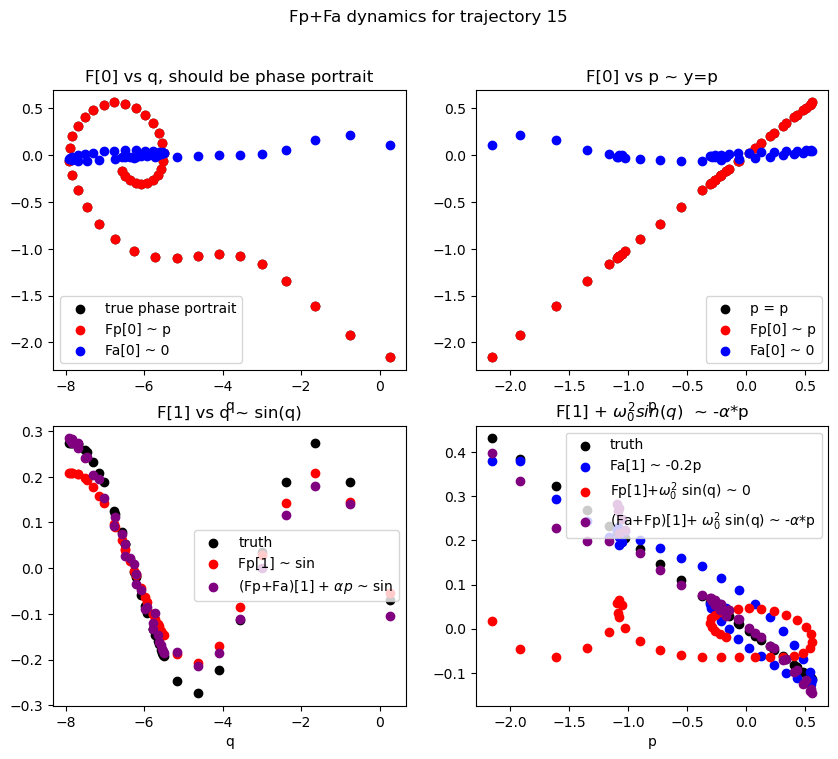

In [493]:
plot_Fp_Fa_out(results_sc22_fa, 15)

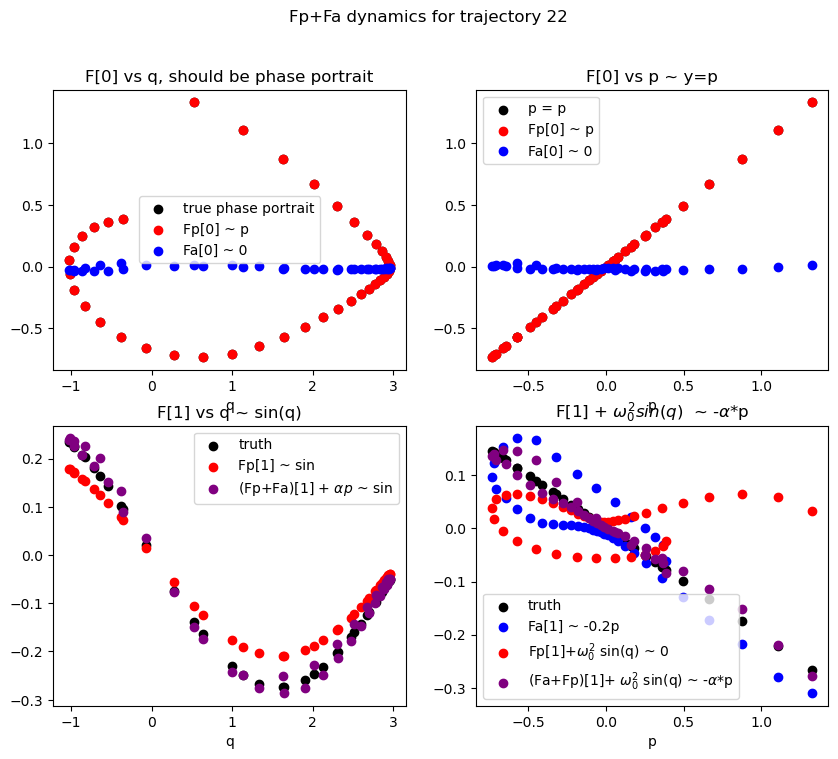

In [494]:
plot_Fp_Fa_out(results_sc22_fa, 22)

## SC3

In [1]:
path_sc3="/Users/mayajanvier/jax-phynity/data/sanity_checks2/none_aug_24_of0iieil/model_3.309e-02.json"
results_sc3, exp_name_sc3, val_loss_sc3 = load_results(path_sc3)
exp_name_sc3, val_loss_sc3

NameError: name 'load_results' is not defined

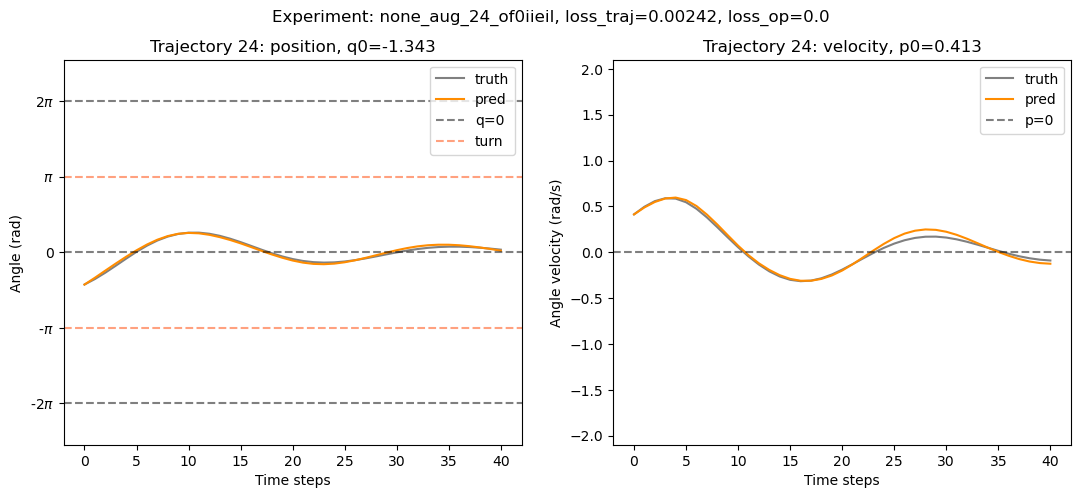

In [330]:
plot_trajectory(results_sc3, exp_name_sc3, 24)

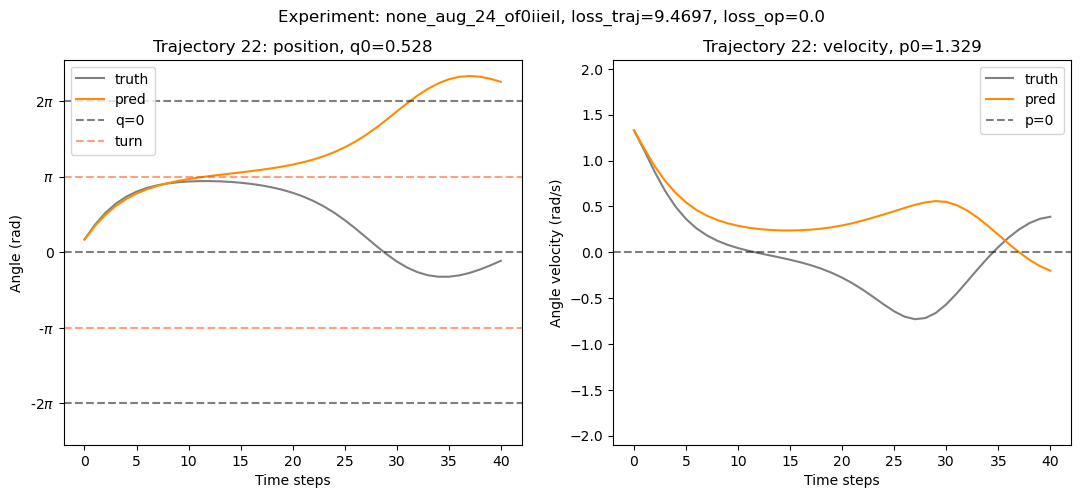

In [331]:
plot_trajectory(results_sc3, exp_name_sc3, 22)

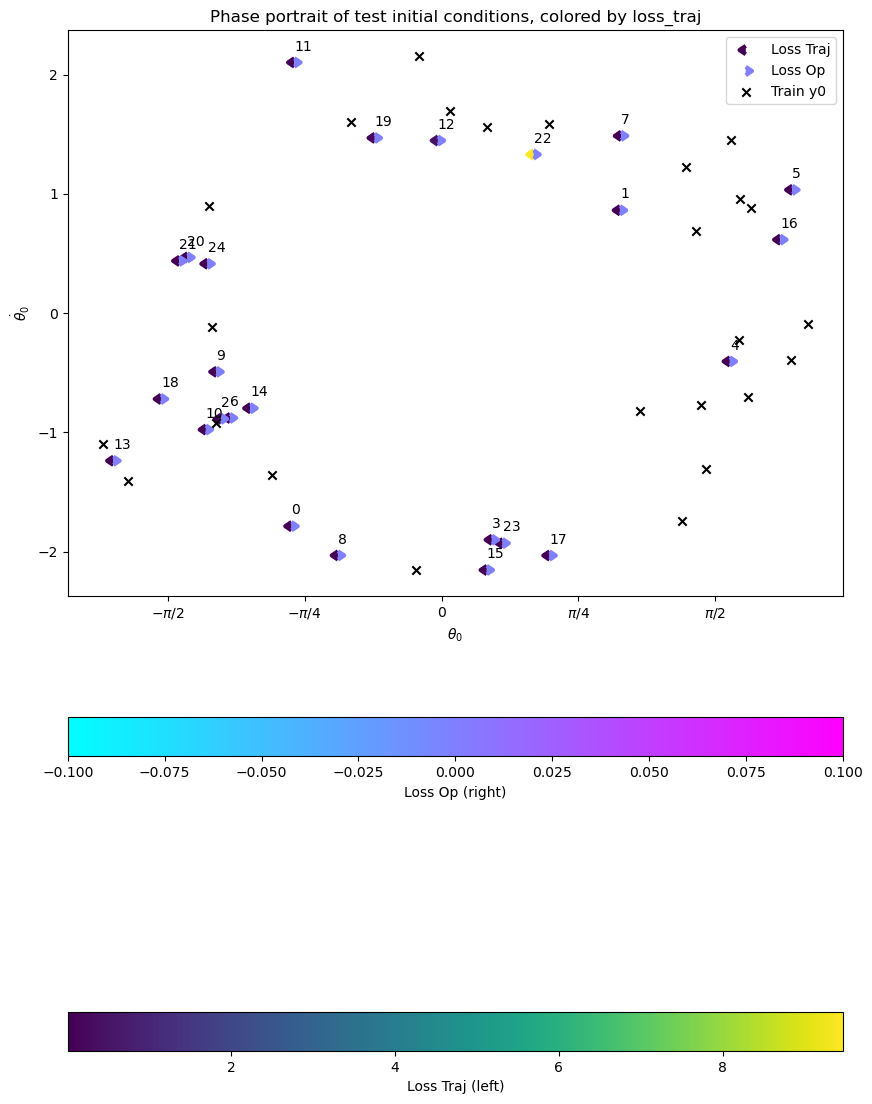

In [380]:
viz_losses_regimes(results_sc3, y0)

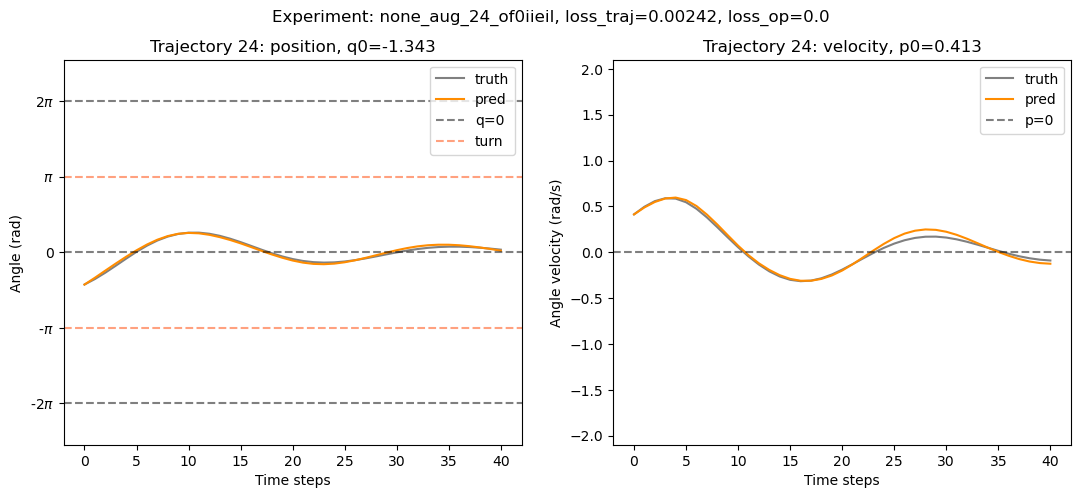

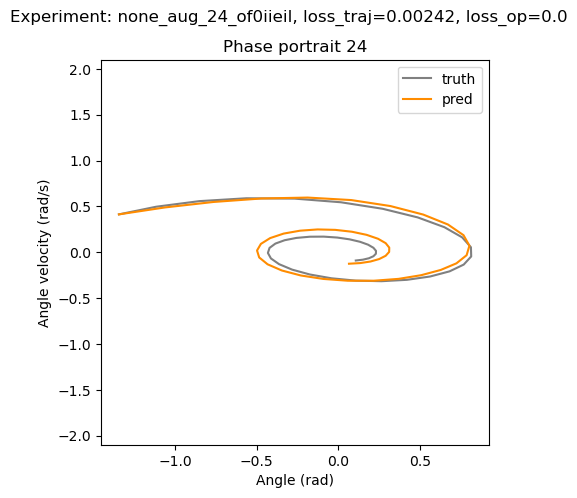

(None, None)

In [393]:
plot_trajectory(results_sc3, exp_name_sc3, 24), plot_phase_trajectory(results_sc3, exp_name_sc3, 24)

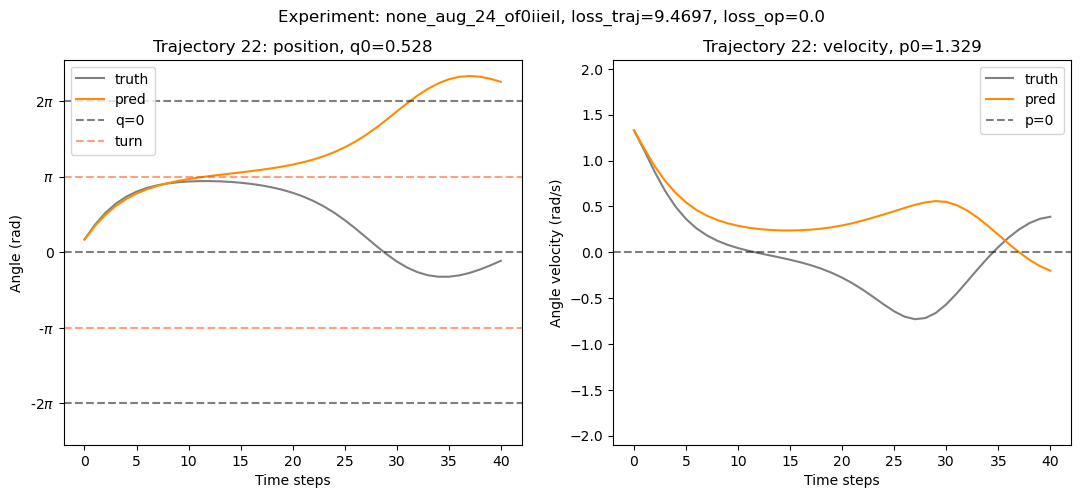

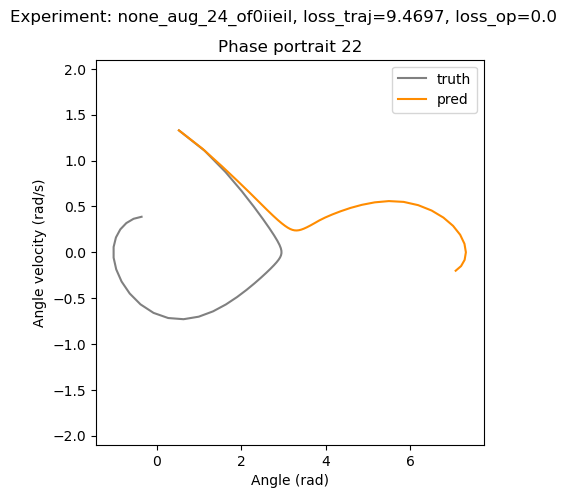

(None, None)

In [394]:
plot_trajectory(results_sc3, exp_name_sc3, 22), plot_phase_trajectory(results_sc3, exp_name_sc3, 22)